# Part 2: Genres and communities and plotting

### *Write about genres and modularity.*

##### *Corresponding text from Week 7 exercise:* ##### 
*Go nuts with an LLM and get all the genres for the nodes in your network*

*Yes, I'm serious. For this one I'd like you to fire up your most powerful thinking model you have access to and get it to write a script to extract genre for all nodes in your network. Some notes to help you*
* *If the node doesn't have an infobox (or if a node's infobox doesn't have a genre it it), just don't assign that node a genre and ignore it in the downstream analysis*
* *Remember to lowercase all genres, also consider simplifying things by mapping rock'n'roll, rock & roll, etc to a single genre.*
* *Remember to test your algorithm well before emplying it, since you're not writing the code yourself, you need to work harder to prove to yourself that it's actually doing what you think it's doing. You should inspect the code to understand what it's actually doing and also test it on the strangest edge-cases you can find. (Can it handle, "The Animals", for example).*
* *The output should be a dictionary mapping artist names to lists of genres (since most artists have multiple genres listed).*

In order to extract the genre information from all the artists pages, I started by loading the network from Github. Each node contains the name of the artist and its corresponding page content.

In [201]:
import urllib
import networkx as nx
import io

# Load the network
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_assignment2/refs/heads/denisa/network.graphml"
    
try:
    with urllib.request.urlopen(url) as response:
        data = response.read()
        
    network = nx.read_graphml(io.BytesIO(data))
    print(f"✓ Network loaded successfully!")
    print(f"  Nodes: {network.number_of_nodes()}")
    print(f"  Edges: {network.number_of_edges()}")
        
except Exception as e:
    print(f"✗ Error loading network: {str(e)}")
    network = None

✓ Network loaded successfully!
  Nodes: 484
  Edges: 7676


I converted the directed graph to undirected (as required by *Note: For this and the next exercise, work on the undirected version of the network.*).

In [202]:
network = network.to_undirected()

With the help of an LLM, I defined a function to extract the genre information from each page.

In [203]:
import os
import json
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import urllib.request

# Helper function to clean the genre text
def clean_genre(genre):
    # Remove reference tags like <ref>...</ref>
    genre = re.sub(r'<ref[^>]*>.*?</ref>', '', genre, flags=re.DOTALL)
    # Remove {{nowrap|...}}
    genre = re.sub(r'\{\{nowrap\|(.*?)\}\}', r'\1', genre)
    # Remove any remaining {{ }}
    genre = re.sub(r'\{\{[^}]*\}\}', '', genre)
    # Remove brackets
    genre = re.sub(r'[\[\]]', '', genre)
    # Clean whitespace
    genre = ' '.join(genre.split())
    # Change to lowercase
    genre = genre.lower().strip()
    
    # Map various rock variants to single genre
    rock_variants = {
        "rock'n'roll": "rock and roll",
        "rock & roll": "rock and roll",
        "rock 'n' roll": "rock and roll",
        "rock n roll": "rock and roll",
        "rock-and-roll": "rock and roll"
    }
    
    if genre in rock_variants:
        return rock_variants[genre]
    
    return genre

# Extract genres list from the wikipedia pages
def extract_genres(content):
    # Parse the JSON structure
    data = json.loads(content)
    
    # Navigate to the wikitext content
    pages = data.get('query', {}).get('pages', {})
    if not pages:
        return []
    
    # Get the page
    page_id = list(pages.keys())[0]
    wikitext = pages[page_id].get('revisions', [{}])[0].get('slots', {}).get('main', {}).get('*', '')
    
    if not wikitext:
        return []
    
    # Extract the Infobox musical artist section
    infobox_pattern = r'\{\{Infobox musical artist(.*?)\n\}\}'
    infobox_match = re.search(infobox_pattern, wikitext, re.DOTALL | re.IGNORECASE)
    
    if not infobox_match:
        return []
    
    infobox_content = infobox_match.group(1)
    
    # Extract genre field
    # Look for | genre = followed by content until the next | field
    genre_pattern = r'\|\s*genre\s*=\s*(.*?)(?=\n\||\n\}\})'
    genre_match = re.search(genre_pattern, infobox_content, re.DOTALL | re.IGNORECASE)
    
    if not genre_match:
        return []

    genre_content = genre_match.group(1).strip()
    
    # Parse genres - they can be in various formats
    genres = []
    
    # Remove {{flatlist| and }} wrappers
    genre_content = re.sub(r'\{\{flatlist\|', '', genre_content, flags=re.IGNORECASE)
    genre_content = re.sub(r'\}\}', '', genre_content)
    
    # Remove wiki formatting like [[Genre]] or [[Genre|display text]]
    # Pattern: [[link]] or [[link|text]]
    wiki_links = re.findall(r'\[\[([^\]|]+)(?:\|[^\]]+)?\]\]', genre_content)
    
    if wiki_links:
        # If we found wiki links, use those
        genres = wiki_links
    else:
        # Otherwise, split by common separators
        # Remove any remaining markup
        genre_content = re.sub(r'<[^>]+>', '', genre_content)
        genre_content = re.sub(r'\*\s*', '', genre_content)
        
        # Split by newlines, commas or bullets
        genre_list = re.split(r'[\n,•]', genre_content)
        genres = [g.strip() for g in genre_list if g.strip()]
    
    # Clean genres
    cleaned_genres = []
    for genre in genres:
        if genre:
            cleaned_genre = clean_genre(genre)
            if cleaned_genre != 'allmusic': # Remove allmusic (discovered during testing)
                cleaned_genres.append(cleaned_genre)
    
    return cleaned_genres

I extracted the genres from each node and added them as a node attribute.

In [204]:
artist_genres = []

for n in network.nodes():
    # Add genres as a list attribute
    genres = extract_genres(network.nodes[n]['content'])
    artist_genres.append(genres)
    network.nodes[n]['genres'] = genres

##### *Corresponding text from Week 7 exercise:* ##### 

*Report the following stats*
* *The number of nodes for which you could find genres*
* *The average number of genres per node*
* *The total number of distinct genres*
* *A histogram showing artist counts for the top 15 genres*

With the help of an LLM, I created a function that generates the above statistics for genres.

In [205]:
# Generate statistics for the nodes with genres
def generate_statistics(nodes_with_genres):
    # 1. Number of nodes with genres
    num_artists_with_genres = len(nodes_with_genres)
    print(f"\n1. Number of artists with genres: {num_artists_with_genres}")
    
    # 2. Average number of genres per node
    total_genres = sum(len(network.nodes[node]['genres']) for node in nodes_with_genres)
    avg_genres = total_genres / num_artists_with_genres if num_artists_with_genres > 0 else 0
    print(f"2. Average number of genres per artist: {avg_genres:.2f}")
    
    # 3. Total number of distinct genres
    all_genres = set()
    for node in nodes_with_genres:
        genres = network.nodes[node]['genres']
        all_genres.update(genres)
    num_distinct_genres = len(all_genres)
    print(f"3. Total number of distinct genres: {num_distinct_genres}")
    
    # 4. Top 15 genres histogram
    genre_counter = Counter()
    for node in nodes_with_genres:
        genres = network.nodes[node]['genres']
        genre_counter.update(genres)
    
    top_15 = genre_counter.most_common(15)
    
    print(f"\n4. Top 15 genres:")
    for i, (genre, count) in enumerate(top_15, 1):
        print(f"   {i:2d}. {genre:30s} - {count:3d} artists")
    
    # Create histogram
    if top_15:
        genres_list, counts = zip(*top_15)
        
        plt.figure(figsize=(14, 8))
        bars = plt.barh(range(len(genres_list)), counts, color='steelblue')
        plt.yticks(range(len(genres_list)), genres_list)
        plt.xlabel('Number of Artists', fontsize=12)
        plt.ylabel('Genre', fontsize=12)
        plt.title('Top 15 Genres by Artist Count', fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()  # Highest at top
        
        # Add count labels on bars
        for i, (bar, count) in enumerate(zip(bars, counts)):
            plt.text(count + 0.5, i, str(count), va='center', fontsize=10)
        
        plt.tight_layout()
        plt.show()
    
    return {
        'num_artists_with_genres': num_artists_with_genres,
        'avg_genres_per_artist': avg_genres,
        'num_distinct_genres': num_distinct_genres,
        'top_15_genres': top_15
    }

I generate statistics for the nodes which I have extracted genres from.


1. Number of artists with genres: 148
2. Average number of genres per artist: 3.72
3. Total number of distinct genres: 144

4. Top 15 genres:
    1. hard rock                      -  33 artists
    2. rock music                     -  32 artists
    3. pop rock                       -  29 artists
    4. alternative rock               -  24 artists
    5. pop music                      -  22 artists
    6. blues rock                     -  22 artists
    7. soft rock                      -  20 artists
    8. folk rock                      -  14 artists
    9. art rock                       -  13 artists
   10. heavy metal music              -  13 artists
   11. rock and roll                  -  13 artists
   12. country rock                   -  12 artists
   13. southern rock                  -  11 artists
   14. indie rock                     -   9 artists
   15. new wave music                 -   9 artists


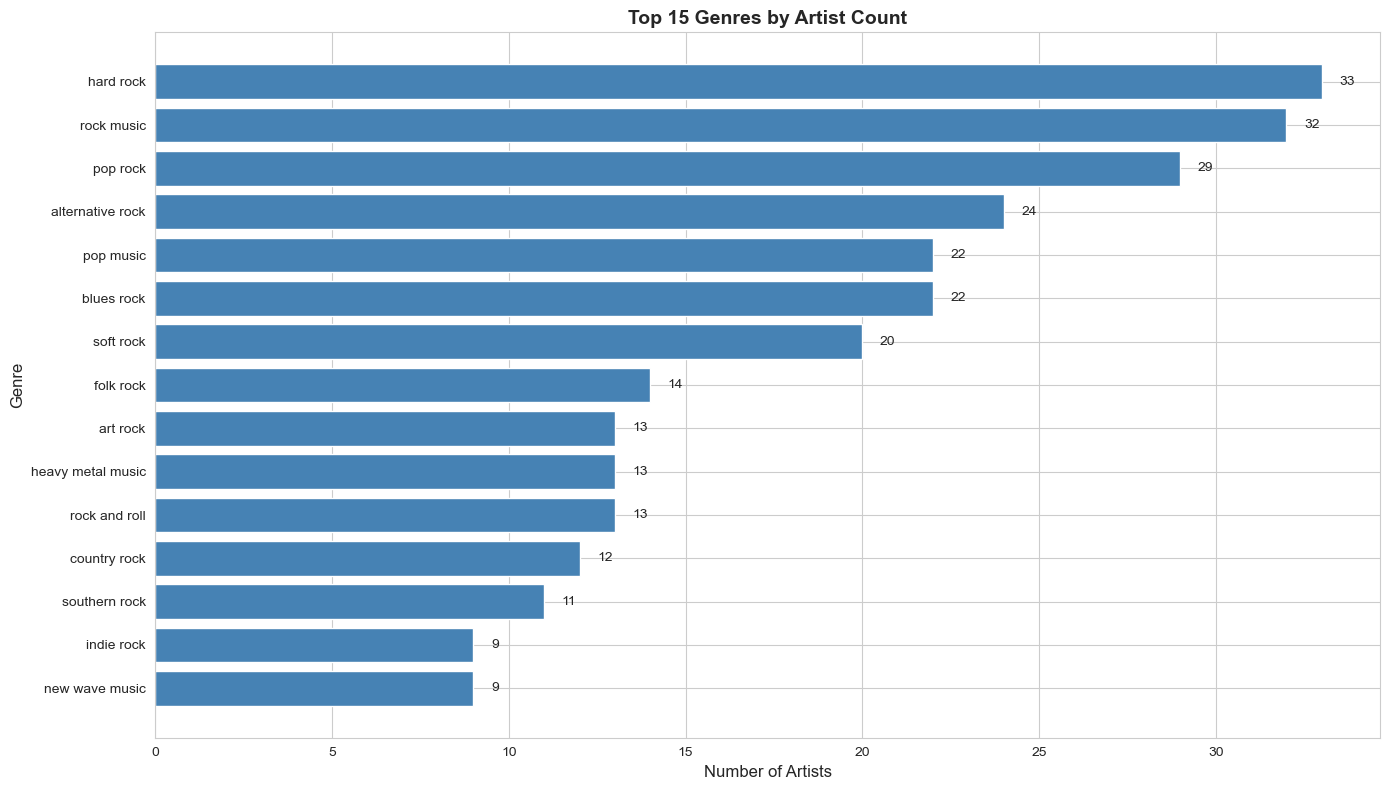

In [206]:
nodes_with_genres = [n for n in network.nodes() if network.nodes[n]['genres']]
stats = generate_statistics(nodes_with_genres)

As expected, the genres are mostly subsets of the rock genre. It can also be observed that Wikipedia considers subgenres of rock but also the broad genres like 'rock music' or 'pop music' when defining the artists. Also an interesting mention is that 'pop music' also appears in the list, so a lot of the artists are actually blending rock and pop music.

For computing modularity, I continue to work with a subnetwork of nodes containing genre information (As required by *Work from the undirected version of the network, keeping only the nodes for which you have genre information.*).

In [207]:
subnetwork = network.subgraph(nodes_with_genres)

##### *Corresponding text from Week 7 exercise:* ##### 

*Explain the concept of modularity in your own words.*

Summarising in my own words what the [Network Science book - Section 9.4](https://networksciencebook.com/chapter/9#modularity) describes, modularity is a measure of a partition's quality, helping to decide if a community partition is better than another one. The higher is a partition's modularity, the better is the structure of the community it describes. 

Overall, the idea behind modularity's computation is that if there are more links inside a community than you’d expect by chance, then those nodes probably form a real community.

### *Detect the communities, discuss the value of modularity in comparison to the genres.*

##### *Corresponding text from Week 7 exercise:*

*Now create your own partition of the network into genres.*
* *Each node is simply characterized by the first genre in its list of genres.*
* *Each community is the group of nodes that share the same genre.*
* *That's all you need, now calculate the modularity of this division of the network into genres.*
* *Note: Modularity is described in the Network Science book, section 9.4.. Thus, use equation 9.12 in the book to calculate the modularity M of the partition described above. Are the genres good communities?*
*Thinking a bit about the underlying data, a potential issue is the following: Many artists have the genre rock as their first genre in the list (since we started from a list of rock bands). So if rock is a big community, the network won't have very high modularity.*

I first created a partition where each node is characterized by the first genre in its list of genres. Each community is the group of nodes that share the same genre.

In [208]:
# Create a partition based on the first genre in the node's list of genres
def create_first_genre_partition(G):
    labels = {}
    
    for node in G.nodes():
        genres = G.nodes[node]['genres']
        if genres:
            labels[node] = genres[0]
    
    # Create communities based on the assigned genres
    communities = defaultdict(list)
    for node, community in labels.items():
        communities[community].append(node)
    return communities


first_partition = create_first_genre_partition(subnetwork)
for key, members in first_partition.items():
    print(f"{key} ({len(members)} members):")
    for m in members:
        print(f"  - {m}")
    print()

roots rock (2 members):
  - john fogerty
  - the band

hard rock (13 members):
  - april wine
  - alice cooper
  - led zeppelin
  - alice cooper (band)
  - joe walsh
  - black stone cherry
  - golden earring
  - grand funk railroad
  - the guess who
  - deep purple
  - new york dolls
  - the cult
  - ted nugent

pop music (3 members):
  - bay city rollers
  - the mamas & the papas
  - abba

rock music (29 members):
  - kenny loggins
  - joan jett|joan jett & the blackhearts
  - roy orbison
  - the hollies
  - tommy james and the shondells
  - peter frampton
  - iggy pop
  - lou reed
  - the boxtones
  - jimi hendrix
  - robert plant
  - little river band
  - bryan adams
  - ringo starr
  - the pretenders
  - the zombies
  - don henley
  - glenn frey
  - joe cocker
  - neil young
  - bob seger|bob seger & the silver bullet band
  - grateful dead
  - stevie nicks
  - dan fogelberg
  - eddie money
  - the beatles
  - huey lewis and the news
  - the doobie brothers
  - christopher cross

p

I defined a function to compute modularity based on the equation 9.12 from the [Network Science book - Section 9.4](https://networksciencebook.com/chapter/9#modularity:~:text=Section%209.4-,Modularity,-In%20a%20randomly).

In [209]:
# Compute modularity based on the equation
def calculate_modularity(G, partition):
    # Get total number of edges
    L = G.number_of_edges()
    
    # Calculate modularity
    modularity = 0.0
    
    for community, nodes in partition.items():
        # Calculate lc: number of edges inside this community
        lc = 0
        for i, node_i in enumerate(nodes):
            for node_j in nodes[i+1:]:  # Only check pairs once
                if G.has_edge(node_i, node_j):
                    lc += 1
        
        # Calculate dc: sum of degrees of all nodes in this community
        dc = sum(G.degree(node) for node in nodes)
        
        # Add contribution of this community to modularity
        # Q = Σc [lc/L - (dc/2L)²]
        modularity += (lc / L) - (dc / (2 * L)) ** 2
    
    return modularity

The partition created leads to a slightly higher than 0 modularity, so the option of defining communities by the first genre in the list is suboptimal.

In [210]:
print(calculate_modularity(subnetwork, first_partition))

0.050978390383592725


##### *Corresponding text from Week 7 exercise:* ##### 

*What happens to the modularity if you use a random genre from the list genre as the node-label for those nodes with more than one genre listed?*

I continued by checking the modularity obtained for a partition defined by a random genre in the node's list of genres.

In [211]:
import random

# Create a partition based on a random genre from the list
def create_genre_random_partition(G):
    labels = {}
    
    for node in G.nodes():
        genres = G.nodes[node]['genres']
        if genres:
            labels[node] = random.choice(genres)
    
    # Create communities based on the assigned genres
    communities = defaultdict(list)
    for node, community in labels.items():
        communities[community].append(node)
    return communities


ranodm_partition = create_genre_random_partition(subnetwork)
for key, members in ranodm_partition.items():
    print(f"{key} ({len(members)} members):")
    for m in members:
        print(f"  - {m}")
    print()

swamp rock (1 members):
  - john fogerty

hard rock (9 members):
  - april wine
  - queens of the stone age
  - midnight oil
  - collective soul
  - pearl jam
  - alice cooper (band)
  - glenn frey
  - grand funk railroad
  - ted nugent

glam rock (3 members):
  - bay city rollers
  - gary glitter
  - slade

soft rock (6 members):
  - kenny loggins
  - steely dan
  - paul mccartney and wings|wings
  - james taylor
  - three dog night
  - air supply

folk rock (6 members):
  - james blunt
  - the byrds
  - the lumineers
  - neil young
  - melissa etheridge
  - sixto rodriguez

pop rock (6 members):
  - x ambassadors
  - five for fighting
  - bryan ferry
  - little river band
  - reo speedwagon
  - kaiser chiefs

rhythm and blues (2 members):
  - mitch ryder
  - jimi hendrix

rock music (13 members):
  - joan jett|joan jett & the blackhearts
  - the hollies
  - peter frampton
  - the boxtones
  - donovan
  - robert plant
  - ringo starr
  - the pretenders
  - don henley
  - grateful dead

The modularity of the random partition is even closer to 0, so it is worse than choosing the first genre from the genre list as a way to define communities.

In [212]:
print(calculate_modularity(subnetwork, ranodm_partition))

0.013742396537456377


##### *Corresponding text from Week 7 exercise:* ##### 
*Discuss your findings - and decide how you want to settle on a single genre for each band.*

I tested also with the second genre in the list, since I had the assumption that the genres will be slightly less broad but still accurately defining the artist's style. However, on computing the modularity the first genre approach had the highest value. This is because using the second genre splits the communities, resulting in more communities with just 1 or 2 members.

In [213]:
# Create a partition based on the second genre in the node's list of genres
def create_second_genre_partition(G):
    labels = {}
    
    for node in G.nodes():
        genres = G.nodes[node]['genres']
        if len(genres)>1:
            # Set the label as the second genre
            labels[node] = genres[1]
    
    # Create communities based on the assigned genres
    communities = defaultdict(list)
    for node, community in labels.items():
        communities[community].append(node)
    return communities


second_partition = create_second_genre_partition(subnetwork)
for key, members in second_partition.items():
    print(f"{key} ({len(members)} members):")
    for m in members:
        print(f"  - {m}")
    print()

rock and roll (2 members):
  - john fogerty
  - gary glitter

edinburgh university press (1 members):
  - bay city rollers

pop music (10 members):
  - kenny loggins
  - roy orbison
  - the hollies
  - donovan
  - ringo starr
  - stevie nicks
  - the beatles
  - edgar winter|the edgar winter group
  - christopher cross
  - the lovin' spoonful

folk rock (4 members):
  - james blunt
  - the lumineers
  - crash test dummies
  - neil young

indie rock (3 members):
  - x ambassadors
  - the stone roses
  - the smiths

rhythm and blues (3 members):
  - mitch ryder
  - chuck berry
  - little richard

hard rock (6 members):
  - joan jett|joan jett & the blackhearts
  - manfred mann's earth band
  - midnight oil
  - collective soul
  - slade
  - zz top

art rock (7 members):
  - peter gabriel
  - lou reed
  - the moody blues
  - simple minds
  - blue october
  - the alan parsons project
  - arcade fire

garage rock revival (1 members):
  - jack white

bubblegum music (1 members):
  - tommy jam

In [214]:
print(calculate_modularity(subnetwork, second_partition))

0.012612718932799465


##### *Corresponding text from Week 7 exercise:* ##### 

*Again, work only with the subnetwork of nodes that have at least one genre.*
*Use the Louvain-algorithm to find communities for the network. Report the value of modularity found by the algorithm.*
*What is the modularity of this partitioning of the network? Is it more community-like than the genres? What does this comparison reveal about the communities?*

I continued by creating a partition with the help of the Louvain Community Detection Algorithm.

In [215]:
louvain_partition = nx.community.louvain_communities(subnetwork, seed=123)

# Convert the list to a dictionary to use the same calculate_modularity function defined above
louvain_dict = {i+1: list(members) for i, members in enumerate(louvain_partition)}

for key, members in louvain_dict.items():
    print(f"{key} ({len(members)} members):")
    for m in members:
        print(f"  - {m}")
    print()

1 (1 members):
  - james blunt

2 (1 members):
  - tommy james and the shondells

3 (18 members):
  - fats domino
  - the moody blues
  - joan jett|joan jett & the blackhearts
  - kaiser chiefs
  - bill haley & his comets
  - jack white
  - electric light orchestra
  - paul mccartney and wings|wings
  - led zeppelin
  - the boxtones
  - the white stripes
  - queens of the stone age
  - the hives
  - little richard
  - robert plant
  - abba
  - tenacious d
  - judas priest

4 (22 members):
  - morrissey
  - the stone roses
  - the pretenders
  - the byrds
  - lou reed
  - ub40
  - simple minds
  - peter gabriel
  - blue october
  - sex pistols
  - iggy pop
  - the bangles
  - the velvet underground
  - alice cooper (band)
  - bryan ferry
  - roxy music
  - the smiths
  - the fixx
  - new york dolls
  - the cult
  - depeche mode
  - arcade fire

5 (1 members):
  - collective soul

6 (1 members):
  - shakin' stevens

7 (1 members):
  - jim croce

8 (1 members):
  - crash test dummies

9 (

The modularity for the Louvain partition is the highest, defining the partition as optimal.

In [216]:
print(calculate_modularity(subnetwork, louvain_dict))

0.32849944120415525


### *Calculate the matrix D and discuss your findings.*

##### *Corresponding text from Week 7 exercise:* ##### 

*Compare the communities found by your algorithm with the music genres by creating a matrix D with dimension (GxC), where G is the 7 most common genres and C is the 7 most common communities (if there are fewer than 7 communities, that's fine, then just work with the communities you have). We set entry D(i,j) to be the number of nodes that genre i has in common with community j. The matrix D is what we call a confusion matrix.*
*Use the confusion matrix to explain how well the communities you've detected correspond to the genres.*
* *Note: This time, use all the genres associate with each node*
* *Note: If a node is not characterized by any of the 7 most popular genres, just ignore it.*
* *Note: If a node is not part of by any of the 7 largest (or fewer, if you only have fewer) communities, just ignore it.*

I used an LLM to help with creating the confusion matrix D plotting the 7 most common genres against the 7 largest communities.

In [217]:
import pandas as pd
import numpy as np
import seaborn as sns

def create_D_matrix(partition):
    # Extract the artists grouped in communities
    community_list = [c for c in partition.values()]
    # Get top 7 genres
    top_genres = [g for g, _ in stats['top_15_genres'][:7]]

    # Get top 7 communities (by size)
    community_sizes = [(idx, len(c)) for idx, c in enumerate(community_list)]
    community_sizes.sort(key=lambda x: x[1], reverse=True)
    top_community_indices = [idx for idx, _ in community_sizes[:7]]
    top_communities = [community_list[idx] for idx in top_community_indices]

    # Map node to its community index
    node_to_community = {}
    for idx in top_community_indices:
        for node in community_list[idx]:
            node_to_community[node] = idx

    # Initialize confusion matrix
    conf_matrix = np.zeros((7, 7), dtype=int)

    # For each node, count genre-community overlap
    for node in subnetwork.nodes():
        genres = subnetwork.nodes[node]['genres']
        if not genres:
            continue
        # Only consider nodes in top communities
        if node not in node_to_community:
            continue
        comm_idx = top_community_indices.index(node_to_community[node])
        # For each genre, if it is in top genres, increment
        for genre in genres:
            if genre in top_genres:
                genre_idx = top_genres.index(genre)
                conf_matrix[genre_idx, comm_idx] += 1

    # Create DataFrame for display
    conf_df = pd.DataFrame(conf_matrix, index=top_genres, columns=[f'Community {list(partition.keys())[i]}' for i in range(7)])
    print("Confusion Matrix (Genres vs Communities):")
    print(conf_df)

    # Interpretation
    plt.figure(figsize=(8,6))
    sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Community")
    plt.ylabel("Genre")
    plt.title("Confusion Matrix: Genre vs Community")
    plt.show()

I first checked the confusion matrix for the partition defined by the first genre in the genre list.

Confusion Matrix (Genres vs Communities):
                  Community roots rock  Community hard rock  \
hard rock                            6                   13   
rock music                          29                    0   
pop rock                             7                    1   
alternative rock                     1                    1   
pop music                           10                    0   
blues rock                           0                    4   
soft rock                            7                    0   

                  Community pop music  Community rock music  \
hard rock                           3                     1   
rock music                          0                     0   
pop rock                            2                     0   
alternative rock                   10                     0   
pop music                           0                     2   
blues rock                          0                     0   
soft rock   

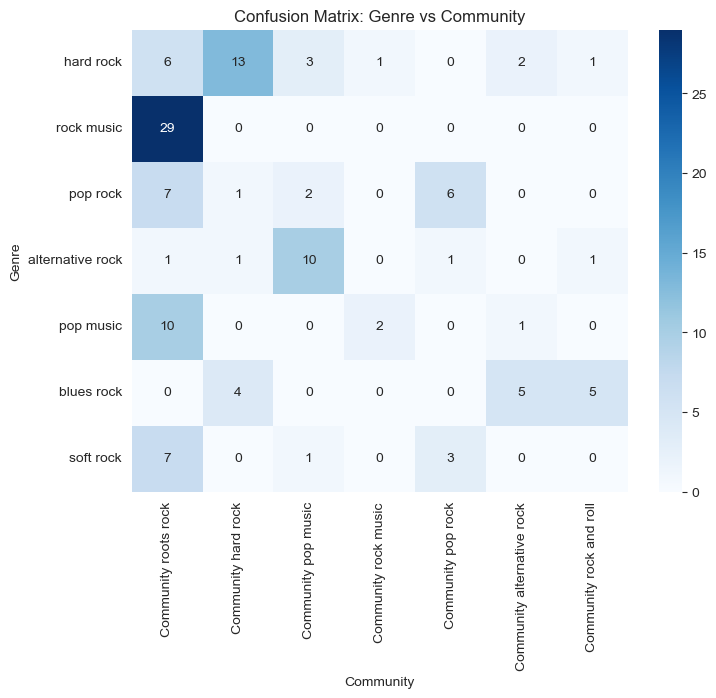

In [218]:
create_D_matrix(first_partition)

The confusion matrix shows that the communities are not accurately corresponding to the genres. This is because the first genre in the infobox usually is the broad 'rock music' genre.

I also plotted the confusion matrix for the Louvain partition.

Confusion Matrix (Genres vs Communities):
                  Community 1  Community 2  Community 3  Community 4  \
hard rock                   7            4            7            5   
rock music                 20            3            2            1   
pop rock                    7            5            3            4   
alternative rock            0            7            1            2   
pop music                  15            0            1            1   
blues rock                  3            0            2           12   
soft rock                  10            0            0            2   

                  Community 5  Community 6  Community 7  
hard rock                   5            4            0  
rock music                  3            0            1  
pop rock                    3            3            2  
alternative rock            4            8            0  
pop music                   1            1            3  
blues rock                  3    

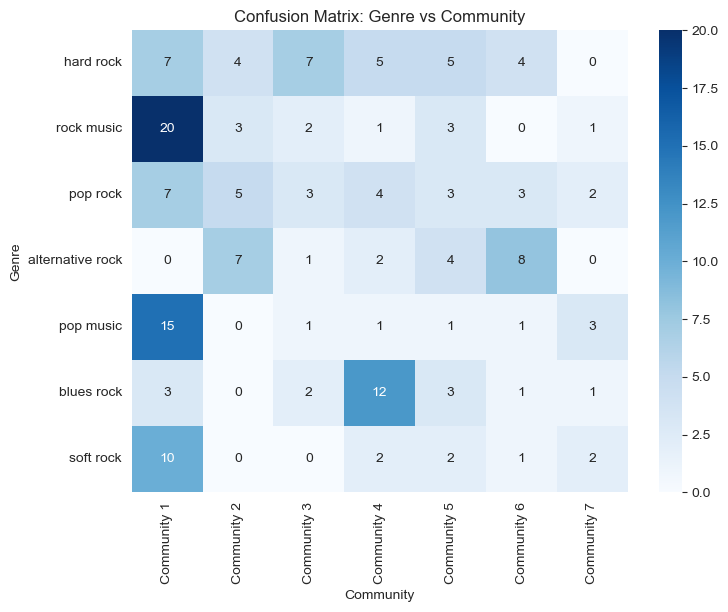

In [219]:
create_D_matrix(louvain_dict)

From the confusion matrix it can be observed that the Louvain partition distributes nodes more widely across genres, as they are not all concentrated on the 'rock music' genre as for the first genre partition.

### *Plot the communities and comment on your results.*

##### *Corresponding text from Week 7 exercise:* ##### 

*Visualize the network, using the Force Atlas algorithm.*
* *This time assign each node a different color based on its structural community.*
* *Note: If there's a lot of small communities, it's OK to only color the 5-10 largest communities (you can make the remaing nodes light gray or some netural color)*
* *Describe the structure you observe.*

With the help of an LLM, I created a function to plot the network with the Force Atlas algorithm.

In [220]:
import matplotlib.colors as mcolors

# Create color map based on partition
def create_color_map(partition, subnetwork):
    # Extract the artists grouped in communities
    community_list = [c for c in partition.values()]
    # Generate a color for each community
    num_communities = len(community_list)
    color_map = list(mcolors.TABLEAU_COLORS.values())
    while len(color_map) < num_communities:
        color_map += list(mcolors.CSS4_COLORS.values())
    colors = color_map[:num_communities]

    # Map node to its community color
    node_colors = []
    node_to_color = {}
    for idx, community in enumerate(community_list):
        for node in community:
            node_to_color[node] = colors[idx]

    for node in subnetwork.nodes():
        node_colors.append(node_to_color.get(node, "#cccccc")) 
    return node_colors

# Plot graph with Force Atlas
def plot_force_atlas(partition, subnetwork):
    node_colors = create_color_map(partition, subnetwork)
    pos = nx.forceatlas2_layout(subnetwork, scaling_ratio=20, gravity=0.1)
    fig, ax = plt.subplots(figsize=(12, 8))
    nx.draw(subnetwork, pos=pos, node_color=node_colors, ax=ax, with_labels=False, node_size=50)
    ax.set_title("Force-Atlas layout colored by community", fontsize=16, pad=14)
    plt.show()

I plotted based on the first genre partition first.

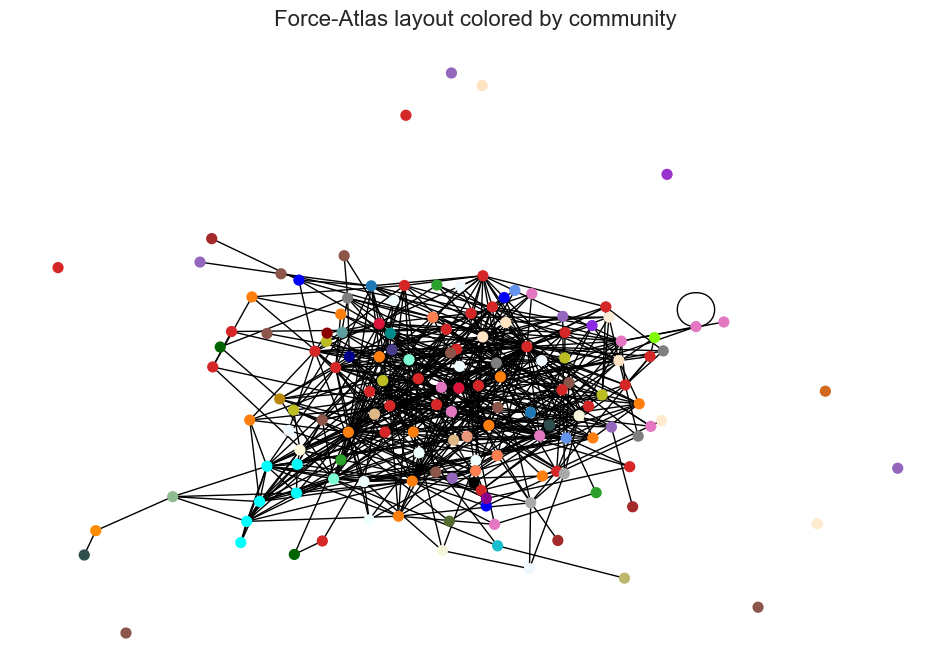

In [221]:
plot_force_atlas(first_partition, subnetwork)

Then, I plotted based on the Louvain partition.

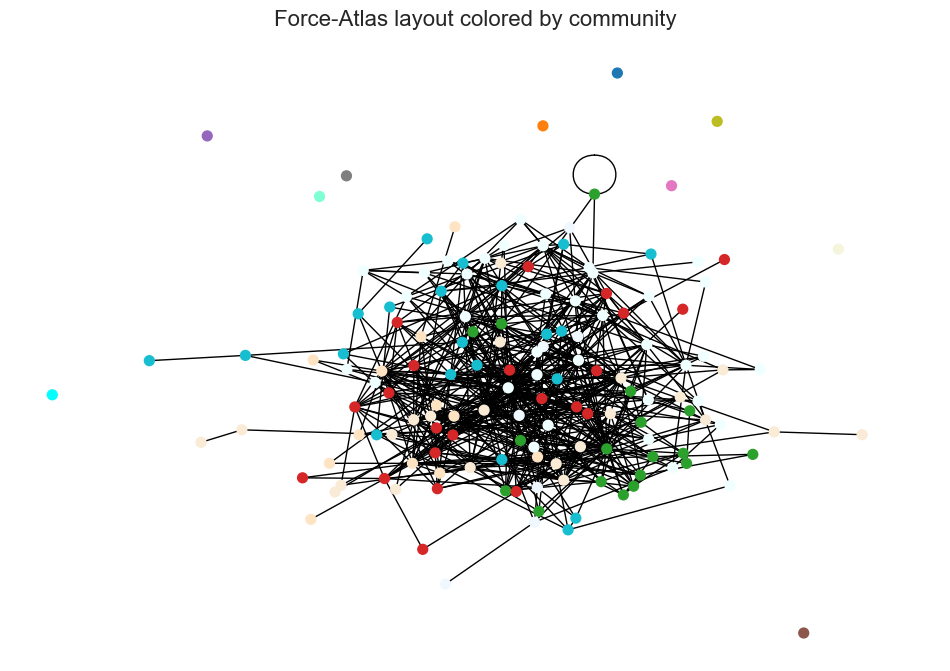

In [222]:
plot_force_atlas(louvain_dict, subnetwork)

With the help of an LLM, I tried another way to visualise the graphs, which would group the nodes in the same community closer together.

In [223]:
import numpy as np

def plot_community_aware(partition, subnetwork):
    # Extract the artists grouped in communities
    community_list = [c for c in partition.values()]
    # Generate a color for each community
    num_communities = len(community_list)

    # Assign each community a block position
    block_positions = {}
    block_size = 10  # Spread between communities
    for idx, community in enumerate(community_list):
        # Place each block along a circle
        angle = 2 * np.pi * idx / num_communities
        block_positions[idx] = (block_size * np.cos(angle), block_size * np.sin(angle))

    # Assign initial positions for each node based on its community
    init_pos = {}
    for idx, community in enumerate(community_list):
        bx, by = block_positions[idx]
        for node in community:
            # Add small random jitter within the block
            init_pos[node] = (bx + np.random.uniform(-1, 1), by + np.random.uniform(-1, 1))

    # Create color map based on partition
    node_colors = create_color_map(partition, subnetwork)

    # Use spring_layout with these initial positions
    pos = nx.spring_layout(subnetwork, pos=init_pos, seed=42, 
                    k=2.0,  # Increased from 0.5
                    iterations=20)

    pos_scaled = {node: (x * 20, y * 20) for node, (x, y) in pos.items()}

    plt.figure(figsize=(24, 20))
    nx.draw(subnetwork, pos=pos_scaled, node_color=node_colors, 
        with_labels=False, node_size=150, edge_color="#cccccc")
    plt.title("Community-aware layout: nodes in same community are closer")
    plt.show()

I plotted the first genre partition with the spring layout.

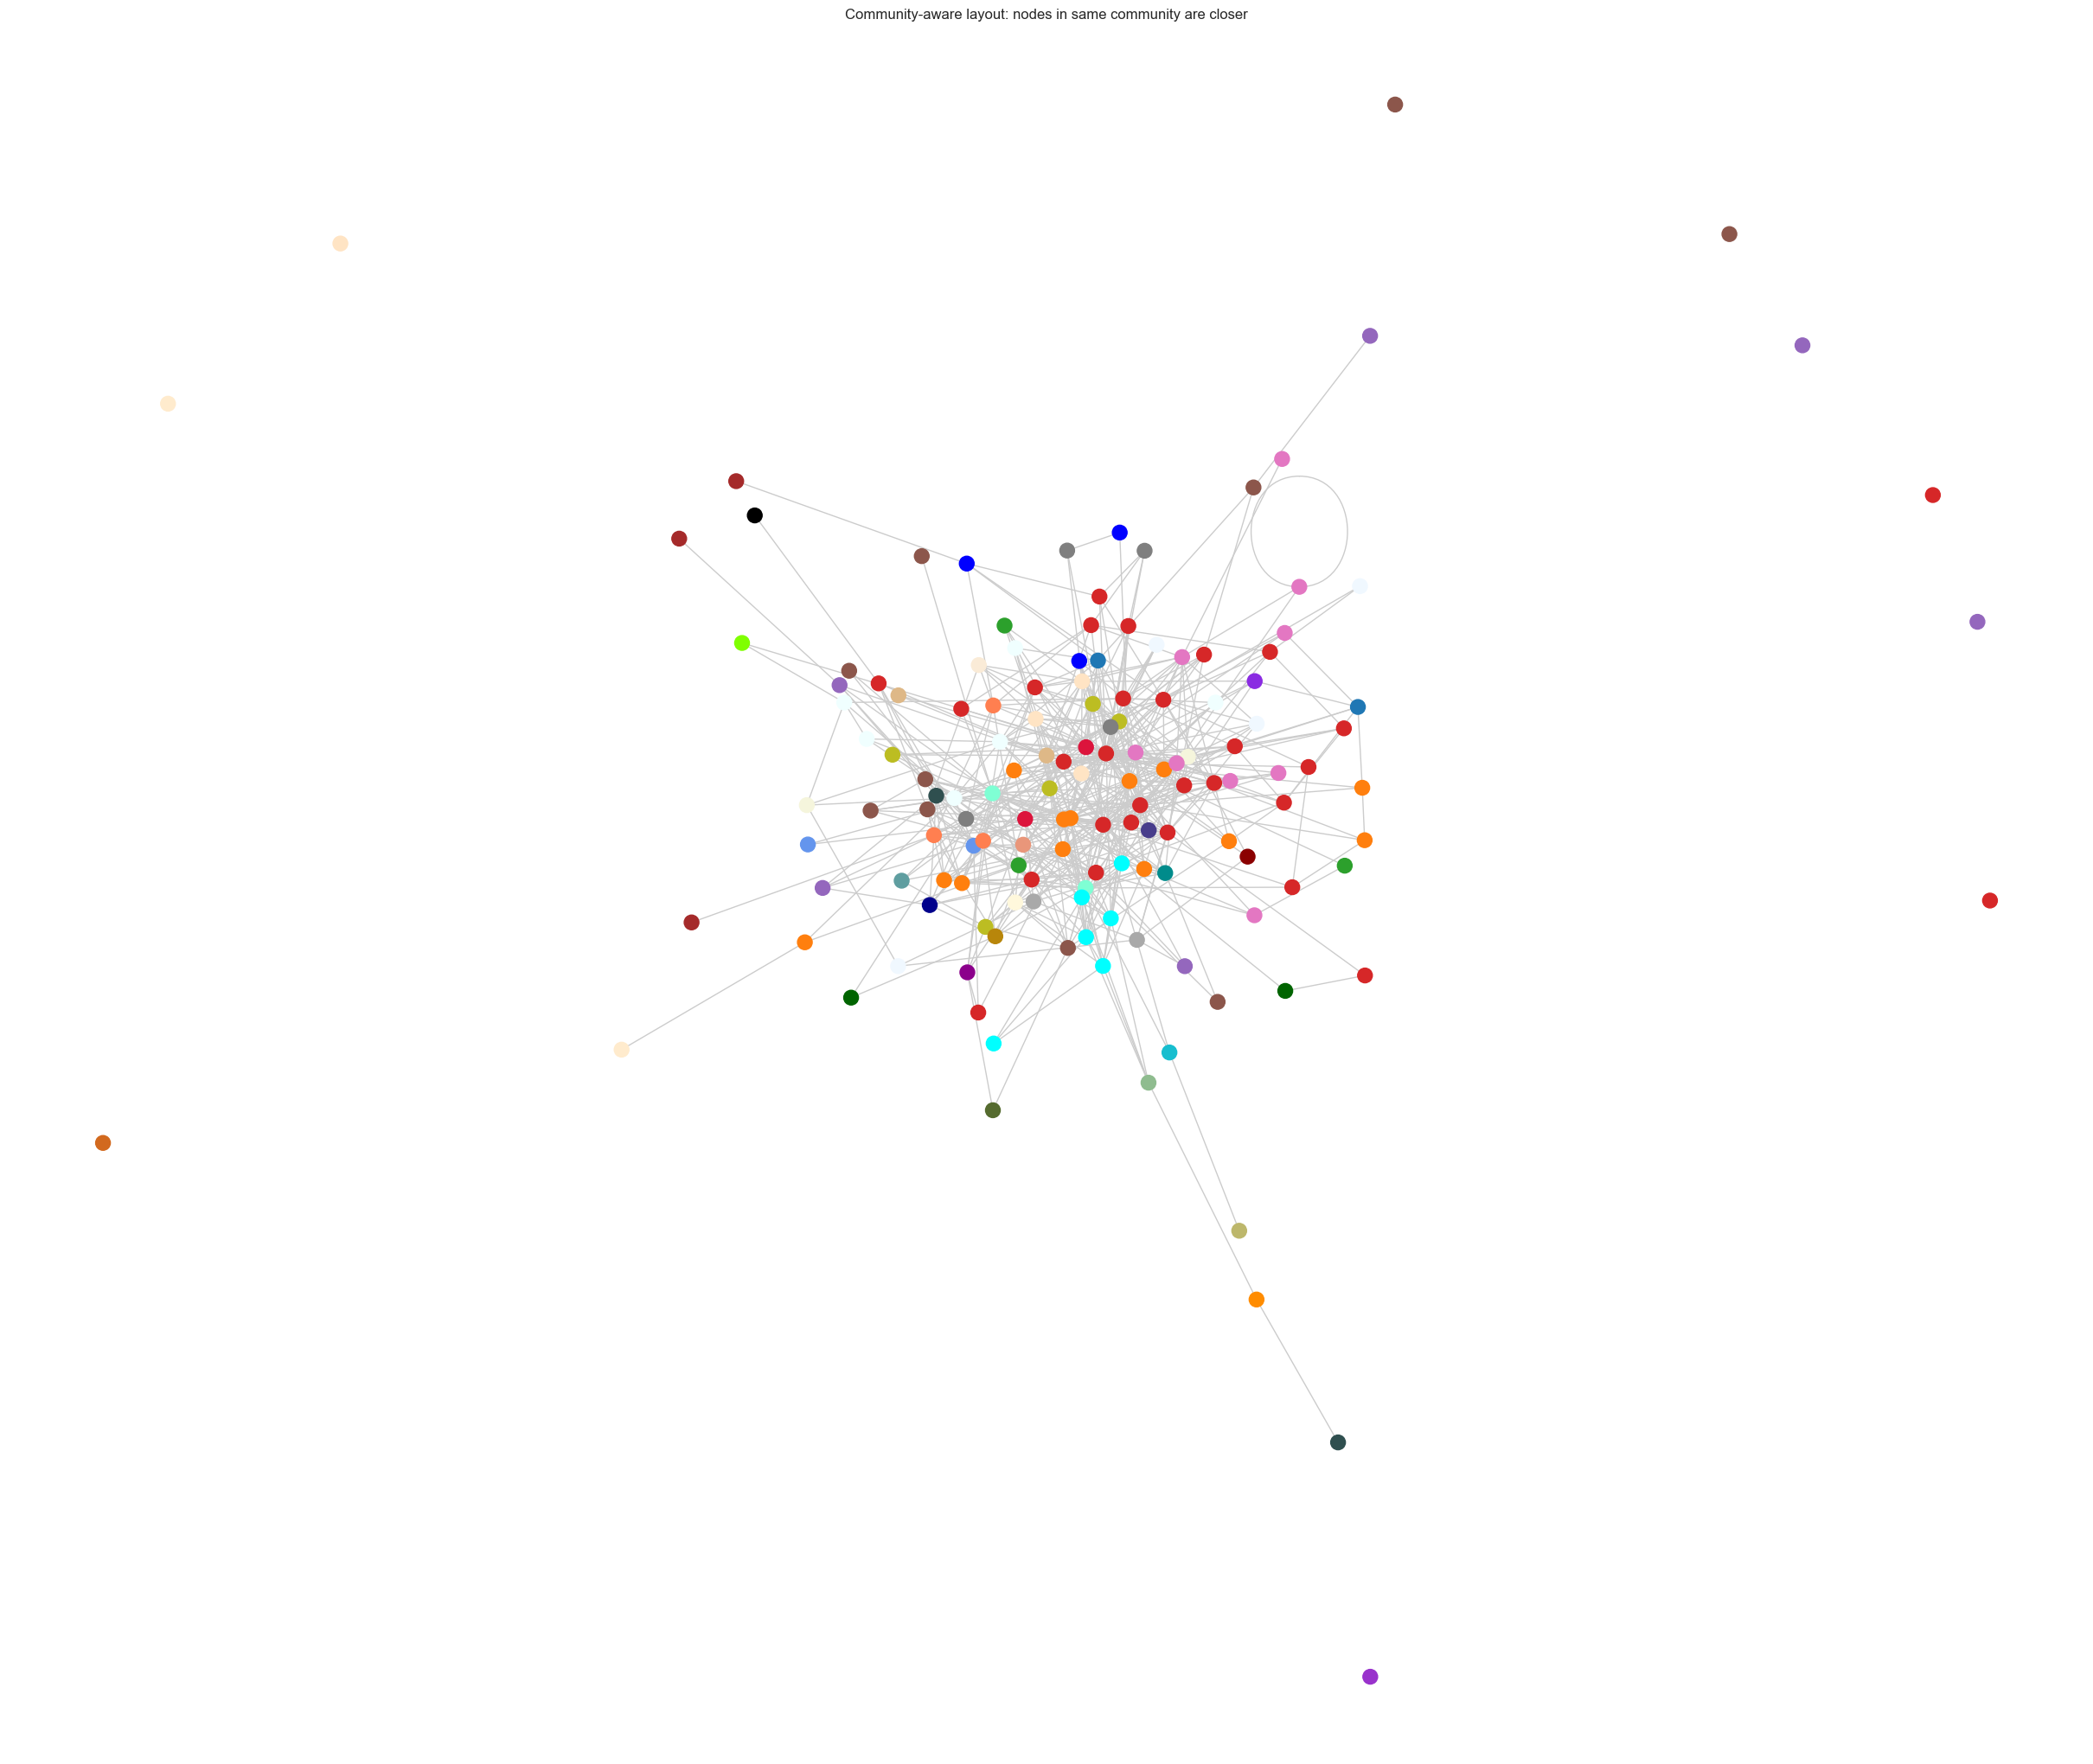

In [224]:
plot_community_aware(first_partition, subnetwork)

The updated function works better for visualising the Louvain partition, emphasizing the grouping.

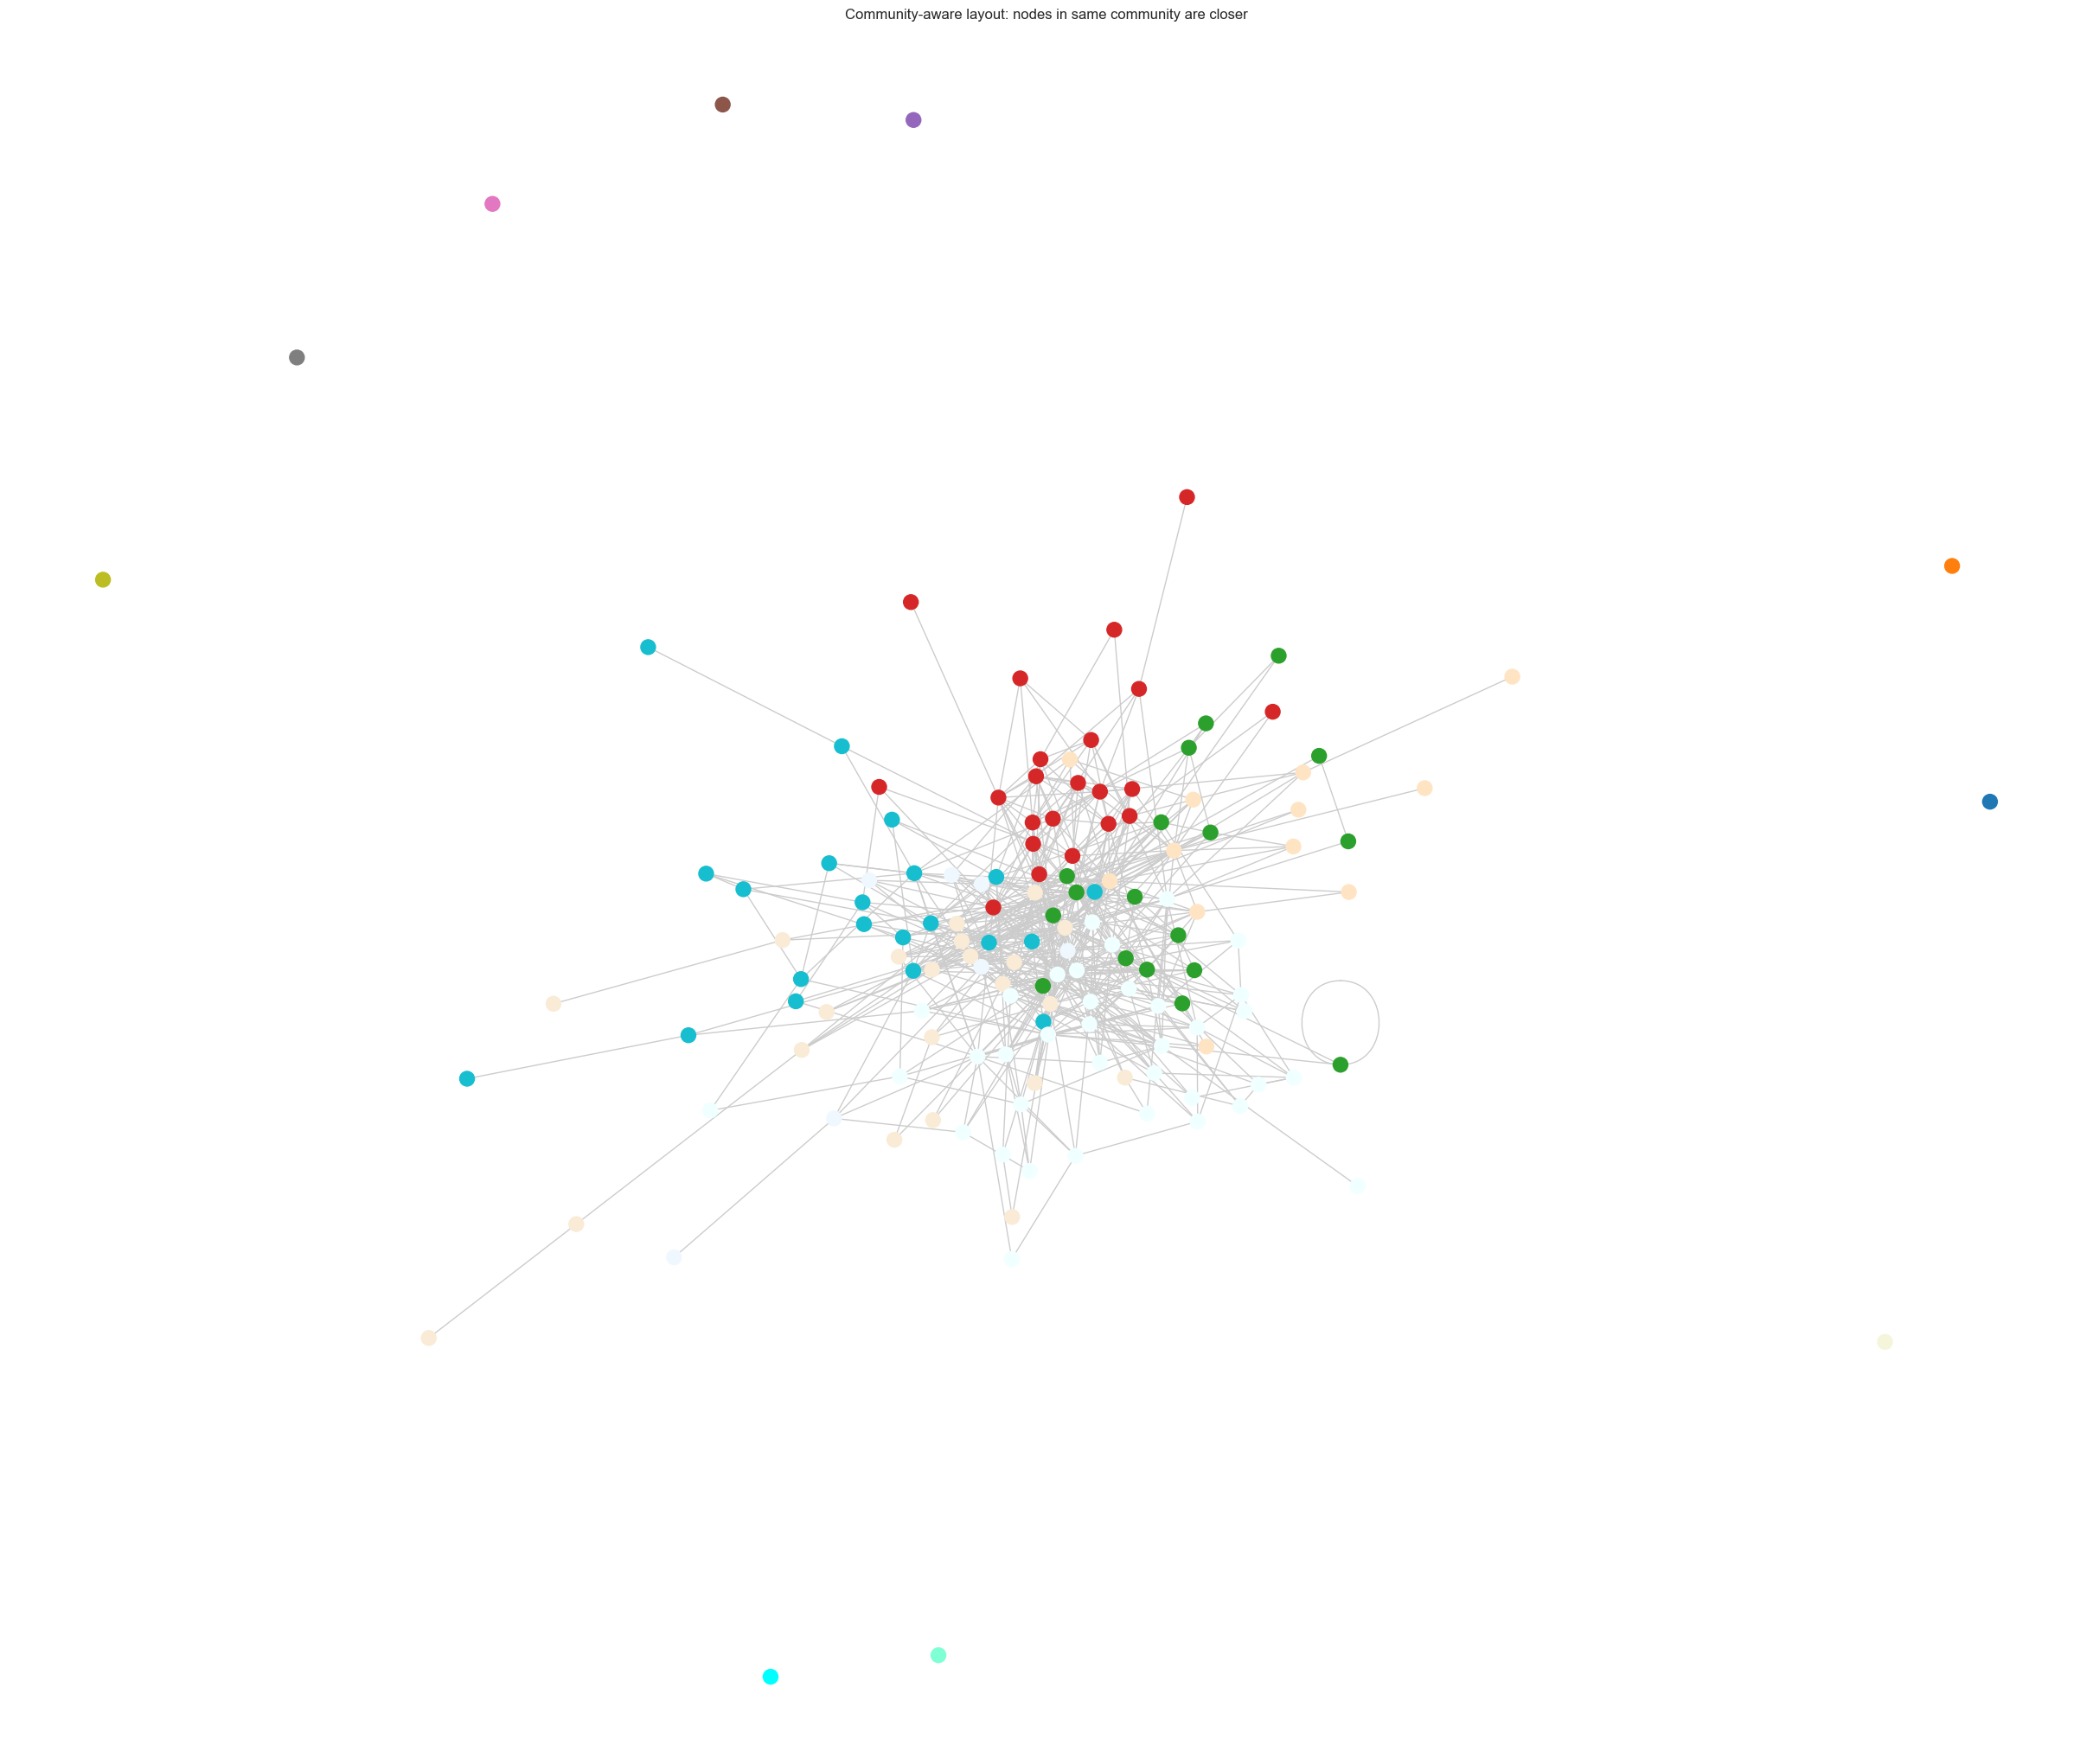

In [225]:
plot_community_aware(louvain_dict, subnetwork)

##### *Corresponding text from Week 7 exercise:* ##### 

*Keep using the community labels from above, but now visualize only the backbone-edges from your favorite network backbone from Week 5. Do the community correspond to the backbone structure you detected?*

In order to visualize the backbone-edges from the network, I download the network's backbone from Github.

In [226]:
# Load the backbone
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_assignment2/refs/heads/denisa/backbone.graphml"
    
try:
    with urllib.request.urlopen(url) as response:
        data = response.read()
        
    backbone = nx.read_graphml(io.BytesIO(data))
    print(f"✓ Backbone network loaded successfully!")
    print(f"  Nodes: {network.number_of_nodes()}")
    print(f"  Edges: {network.number_of_edges()}")
        
except Exception as e:
    print(f"✗ Error loading network: {str(e)}")
    backbone = None

✓ Backbone network loaded successfully!
  Nodes: 484
  Edges: 6301


First, I plotted the first genre partition of the backbone with the Force Atlas algorithm.

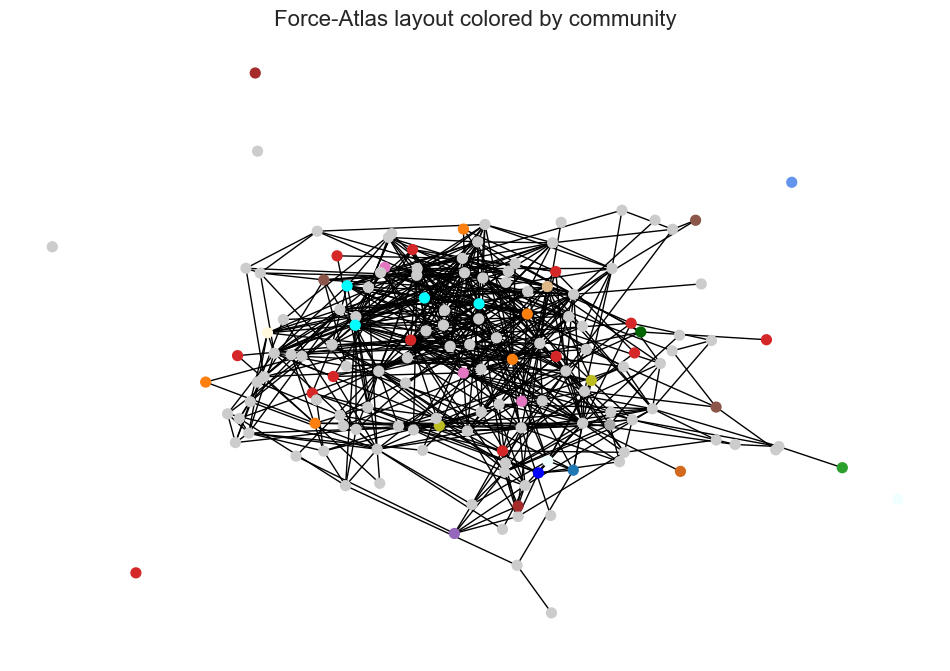

In [227]:
plot_force_atlas(first_partition, backbone)

I also plotted with my custom visualization function.

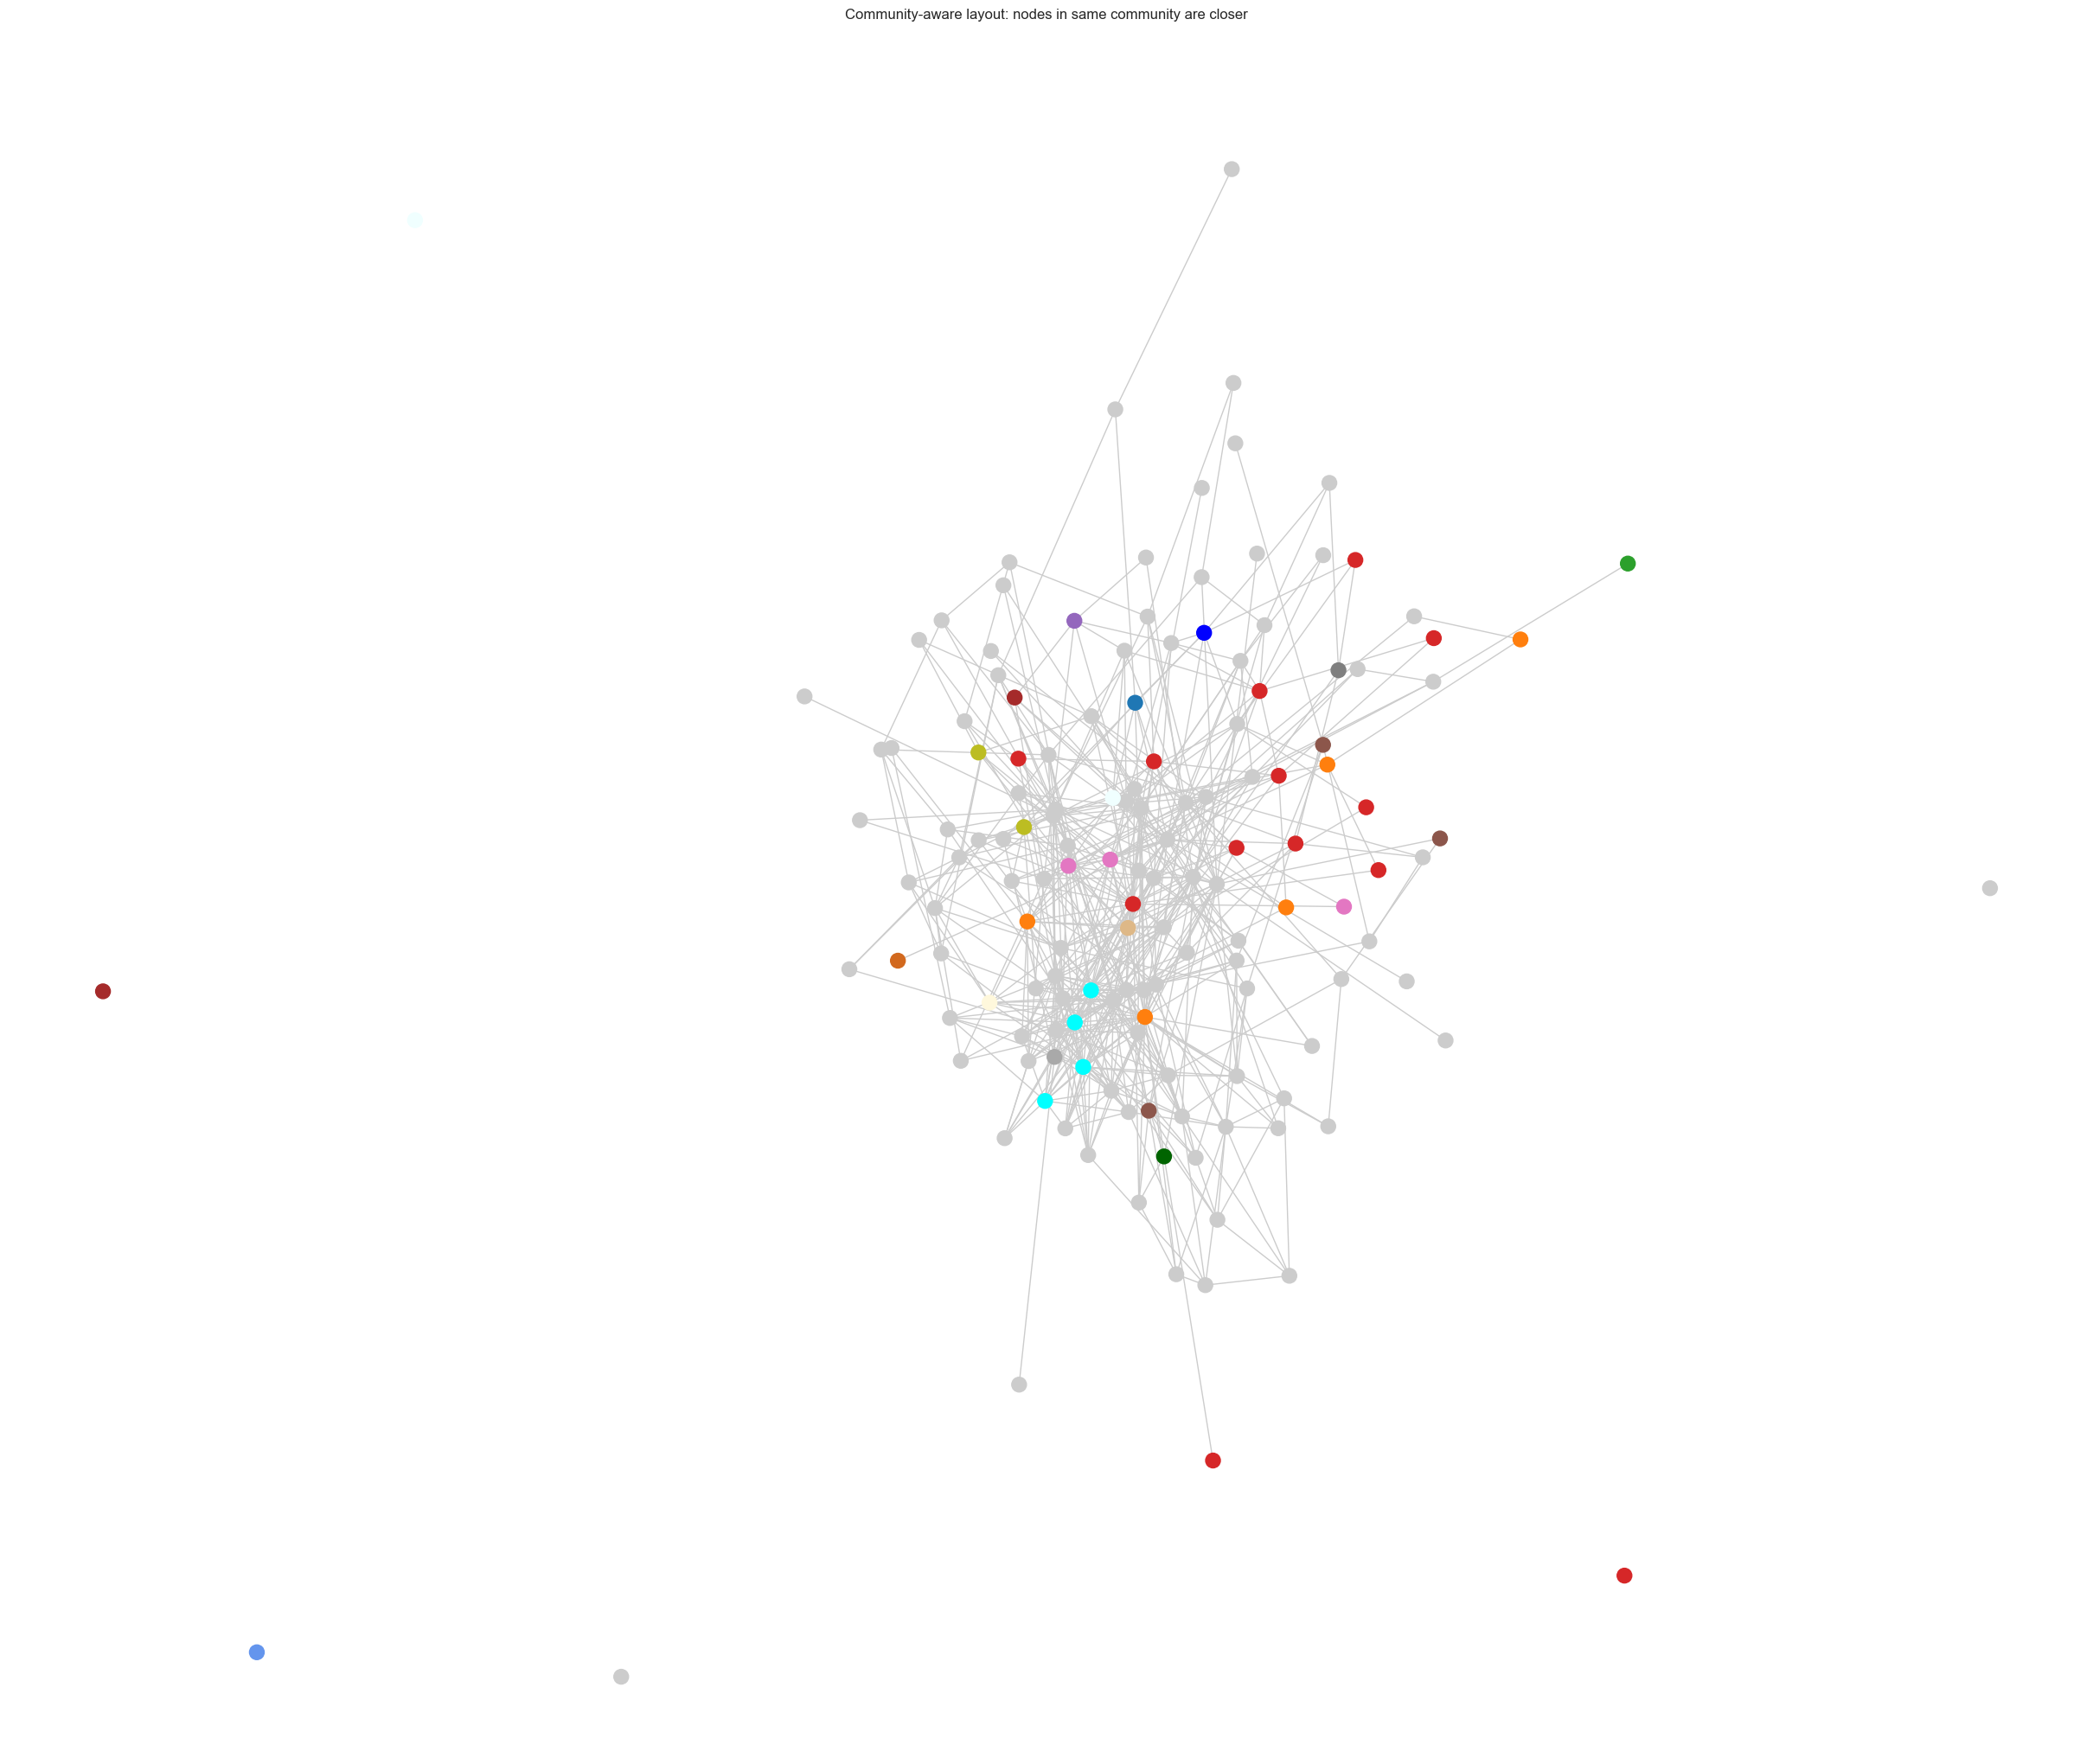

In [228]:
plot_community_aware(first_partition, backbone)

I plotted the Louvain partition of the backbone with Force Atlas.

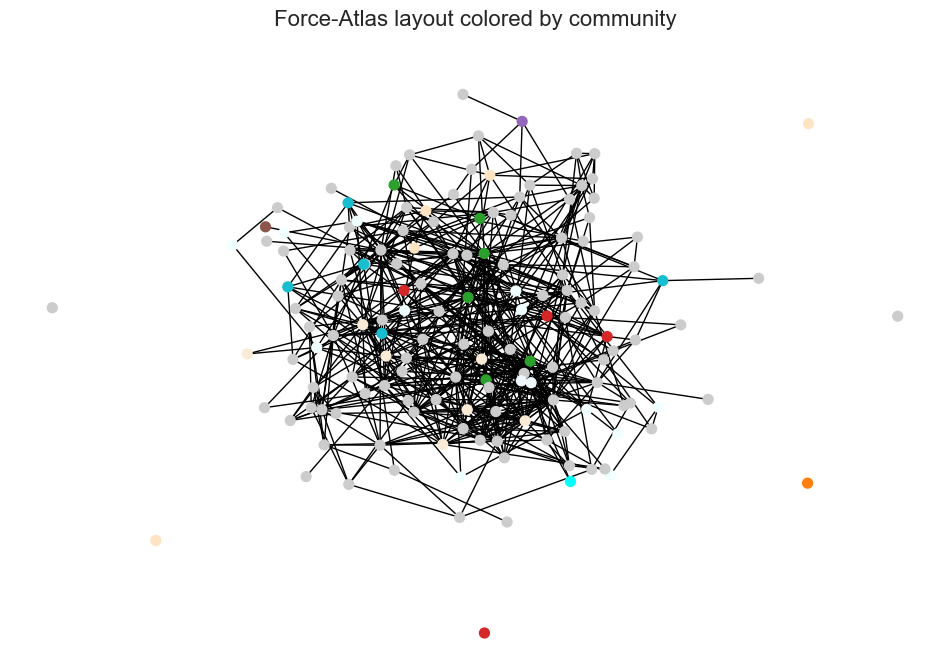

In [229]:
plot_force_atlas(louvain_dict, backbone)

Finally, I plotted with the help of my custom visualization function.

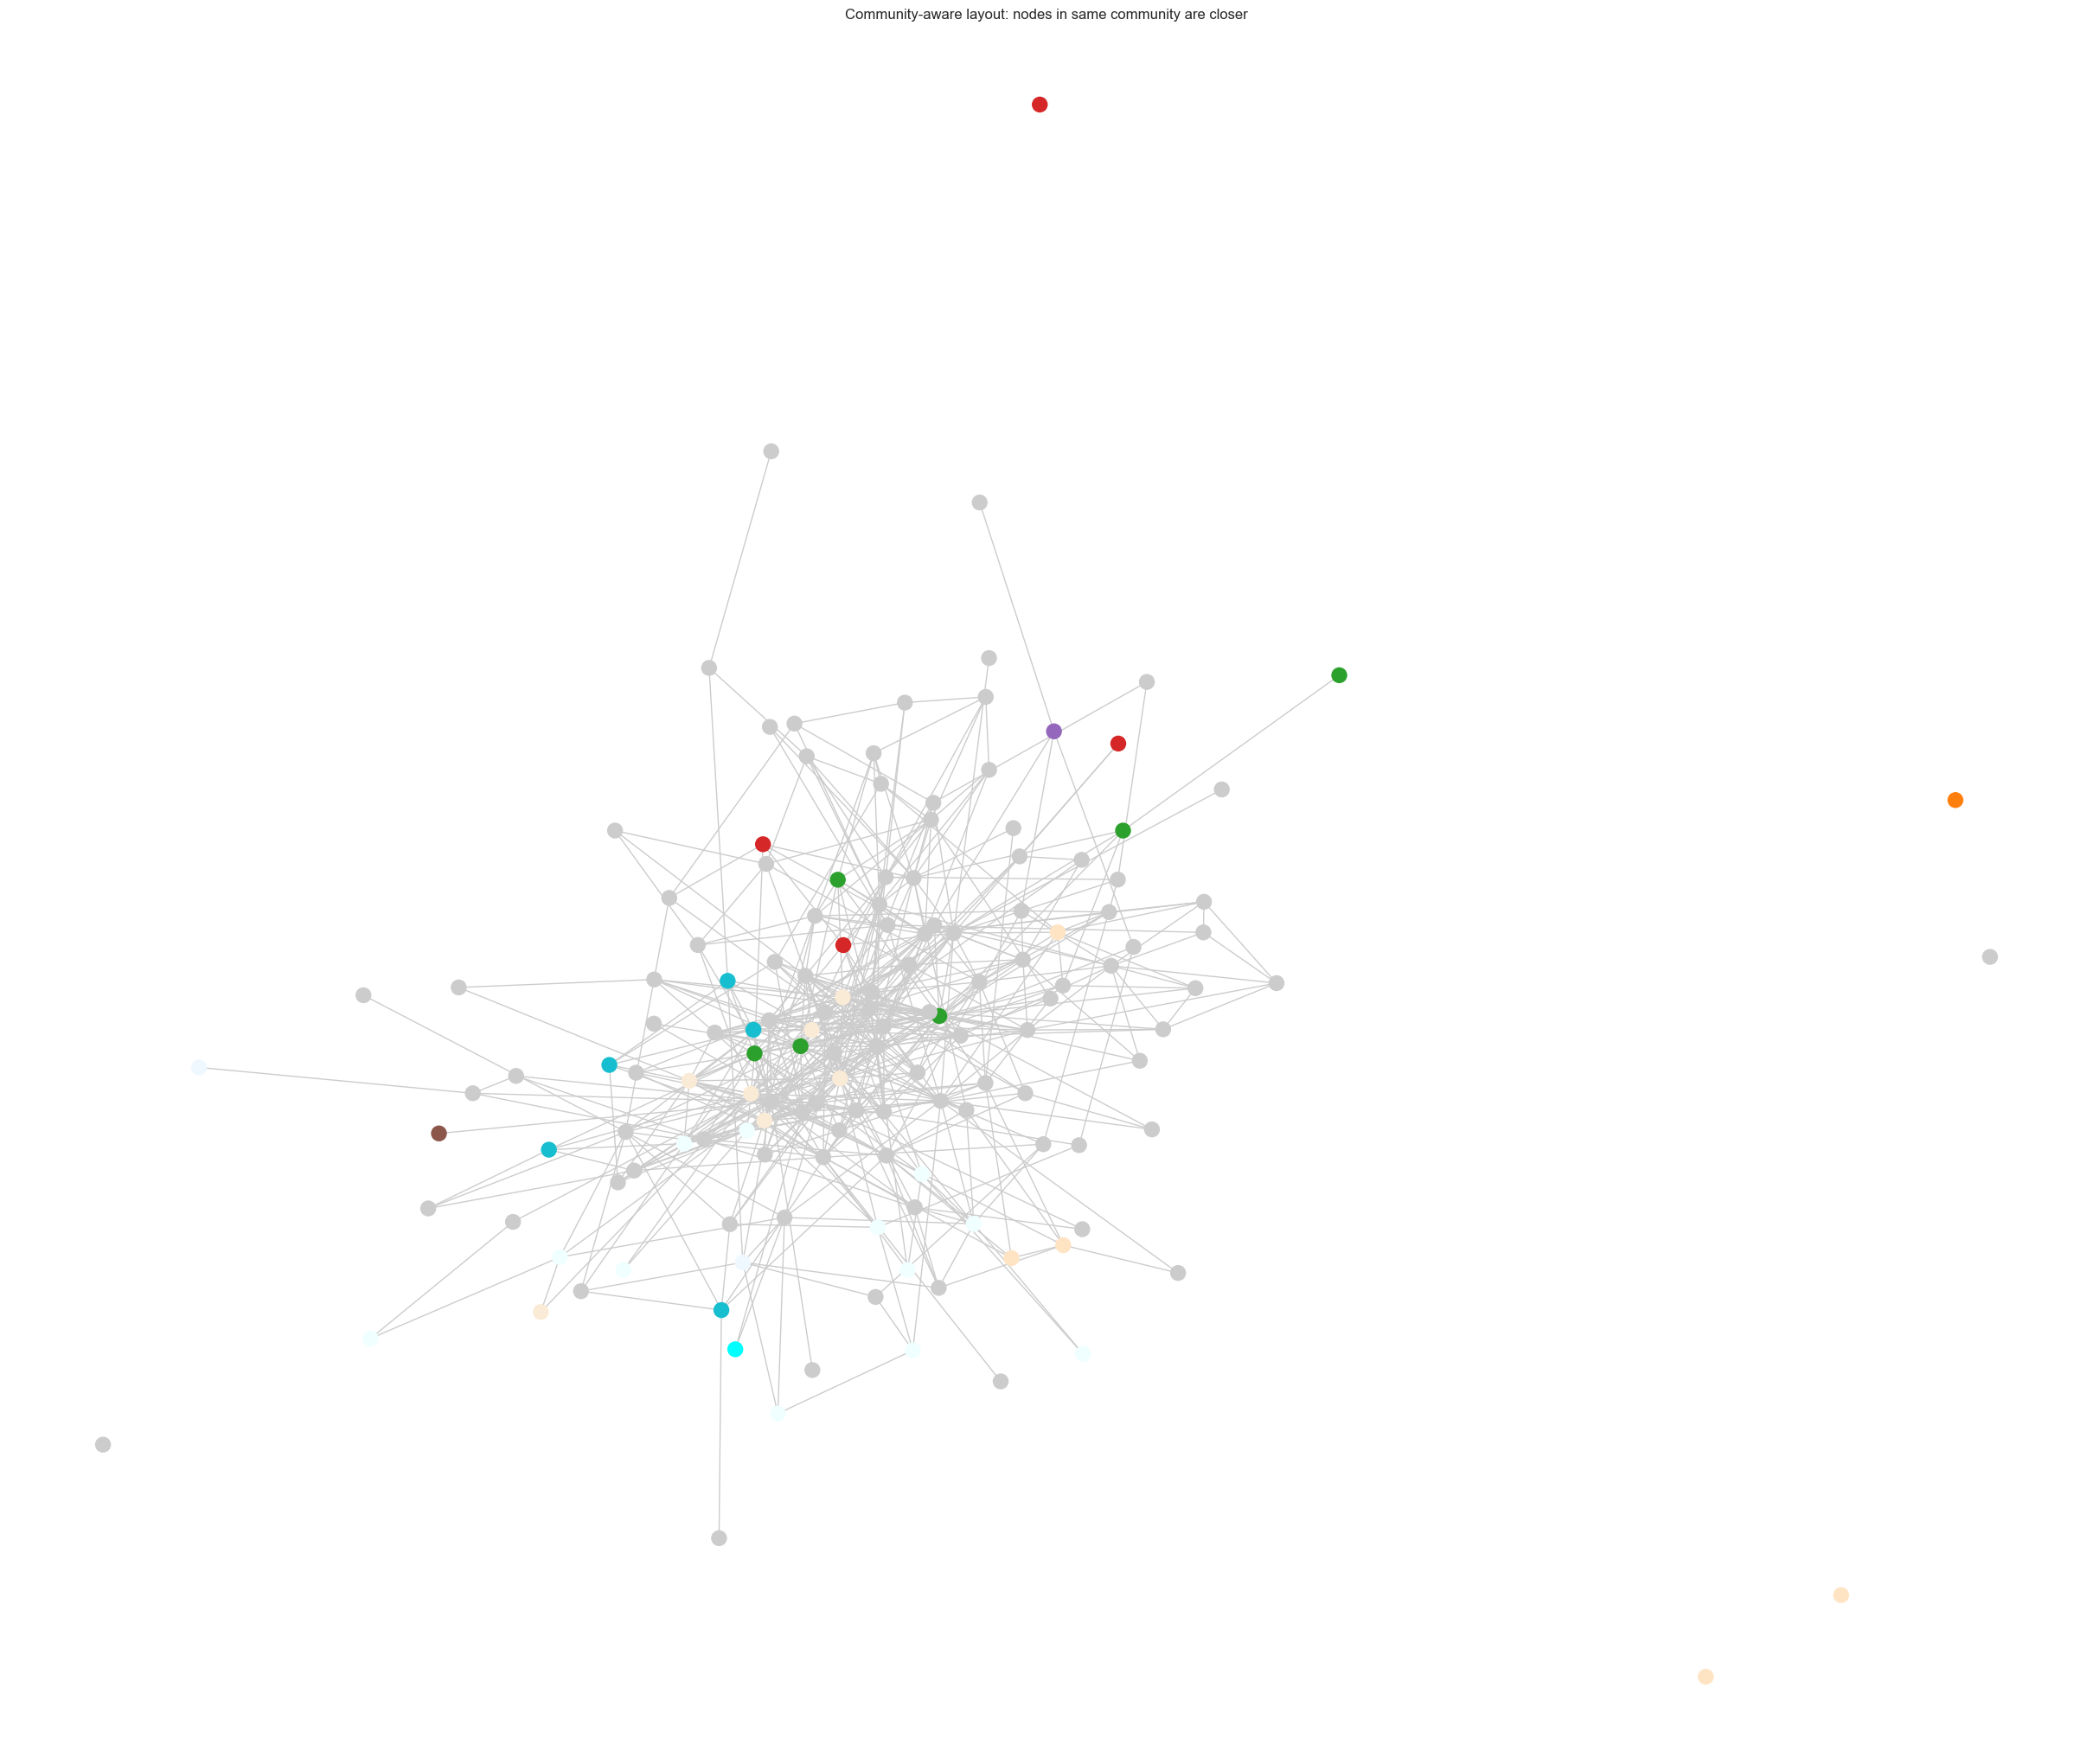

In [230]:
plot_community_aware(louvain_dict, backbone)

In [231]:
n = len(louvain_dict) if len(louvain_dict) < 7 else 7

sorted_community_sizes = sorted([(len(members), comm_id) for comm_id, members in louvain_dict.items()])[::-1]
top_communities = [comm_id for count, comm_id in sorted_community_sizes][:n]


top_genres = [genre for genre, count in stats['top_15_genres'][:n]]
print(f"Top {n} genres: {top_genres}\n")
print(f"Top {n} communities: {top_communities}")

Top 7 genres: ['hard rock', 'rock music', 'pop rock', 'alternative rock', 'pop music', 'blues rock', 'soft rock']

Top 7 communities: [15, 12, 4, 10, 3, 17, 11]


In [232]:
def load_content(content):
    # Parse the JSON structure
    data = json.loads(content)
    
    # Navigate to the wikitext content
    pages = data.get('query', {}).get('pages', {})
    if not pages:
        return ""
    
    # Get the page
    page_id = list(pages.keys())[0]
    wikitext = pages[page_id].get('revisions', [{}])[0].get('slots', {}).get('main', {}).get('*', '')
    
    return wikitext

In [233]:
genre_docs = {}
for nodes in subnetwork.nodes():
    genres = subnetwork.nodes[nodes]['genres']
    content = load_content(subnetwork.nodes[nodes]['content'])
    for genre in genres:
        if genre in top_genres:
            if genre not in genre_docs:
                genre_docs[genre] = []
            genre_docs[genre].append(content)
for genre, docs in genre_docs.items():
    genre_docs[genre] = ' '.join(docs)
    print(f"Genre: {genre}, Number of documents: {len(docs)}, Length of combined text: {len(genre_docs[genre]):,} characters")
print(f"\n{len(genre_docs)} genre documents prepared\n")

Genre: blues rock, Number of documents: 22, Length of combined text: 1,533,776 characters
Genre: hard rock, Number of documents: 33, Length of combined text: 2,631,061 characters
Genre: pop music, Number of documents: 22, Length of combined text: 1,886,234 characters
Genre: pop rock, Number of documents: 29, Length of combined text: 1,921,320 characters
Genre: rock music, Number of documents: 32, Length of combined text: 2,995,219 characters
Genre: soft rock, Number of documents: 20, Length of combined text: 1,357,182 characters
Genre: alternative rock, Number of documents: 24, Length of combined text: 2,228,200 characters

7 genre documents prepared



In [234]:
community_docs = {}
for comm_id in top_communities:
    members = louvain_dict[comm_id]
    for node in members:
        content = load_content(subnetwork.nodes[node]['content'])
        if comm_id not in community_docs:
            community_docs[comm_id] = []
        community_docs[comm_id].append(content)
for comm_id, docs in community_docs.items():
    community_docs[comm_id] = ' '.join(docs)
    print(f"Community ID: {comm_id}, Number of documents: {len(docs)}, Length of combined text: {len(community_docs[comm_id]):,} characters")
print(f"\n{len(community_docs)} community documents prepared\n")

Community ID: 15, Number of documents: 36, Length of combined text: 2,909,731 characters
Community ID: 12, Number of documents: 22, Length of combined text: 2,096,136 characters
Community ID: 4, Number of documents: 22, Length of combined text: 1,953,720 characters
Community ID: 10, Number of documents: 21, Length of combined text: 1,293,868 characters
Community ID: 3, Number of documents: 18, Length of combined text: 1,683,806 characters
Community ID: 17, Number of documents: 12, Length of combined text: 1,066,362 characters
Community ID: 11, Number of documents: 7, Length of combined text: 347,843 characters

7 community documents prepared



In [235]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/kyleelyk/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [236]:
def clean_and_tokenize(text):
    # Remove URLs and web-specific content
    text = re.sub(r'https?://\S+', '', text)  # Remove http/https URLs
    text = re.sub(r'www\.\S+', '', text)  # Remove www. domains
    text = re.sub(r'\S+\.(com|org|net|edu|gov|uk)\b', '', text, flags=re.IGNORECASE)
    
    # Remove Wikipedia/HTML markup
    text = re.sub(r'\{\{[^}]+\}\}', '', text)  # Remove {{template}}
    text = re.sub(r'\[\[[^\]]+\]\]', '', text)  # Remove [[links]]
    text = re.sub(r'<ref[^>]*>.*?</ref>', '', text, flags=re.DOTALL)  # Remove <ref> tags
    text = re.sub(r'<[^>]+>', '', text)  # Remove all HTML tags
    text = re.sub(r'\[\[(Category|File|Image):[^\]]+\]\]', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\bstyle\s*=\s*["\'][^"\']*["\']', '', text)  # Remove style attributes
    text = re.sub(r'\b(align|valign|colspan|rowspan|width|height)\b\s*=\s*\S+', '', text)
    
    # Set everything to lowercase
    text = text.lower()
    
    # Remove all punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Tokenize (split by whitespace)
    tokens = text.split()
    
    # Filter, remove stop words, and lemmatize
    cleaned_tokens = []
    for token in tokens:
        # Skip stop words
        if token in stop_words:
            continue
        
        # Skip if not alphabetic
        if not token.isalpha():
            continue
        
        # Skip very short words
        if len(token) < 3:
            continue
        
        # Skip very long words
        if len(token) > 20:
            continue
        
        # Lemmatize to reduce inflectional forms to base form
        lemmatized = lemmatizer.lemmatize(token)
        
        # Add to cleaned tokens
        cleaned_tokens.append(lemmatized)
    
    return cleaned_tokens

In [237]:
def compute_tf_idf(documents_dict, min_df=2):
    # Tokenize and compute term frequencies
    doc_term_freq = {}
    doc_total_terms = {}

    for doc_id, text in documents_dict.items():
        tokens = clean_and_tokenize(text)
        term_counts = Counter(tokens)
        doc_term_freq[doc_id] = term_counts
        doc_total_terms[doc_id] = len(tokens)
        print(f"  ✓ Document '{doc_id}': {len(tokens):,} tokens, {len(term_counts):,} unique terms")
    
    # Compute document frequency for each term
    term_doc_freq = Counter()
    all_terms = set()
    
    for doc_id, term_counts in doc_term_freq.items():
        for term in term_counts.keys():
            term_doc_freq[term] += 1
            all_terms.add(term)

    # Filter by document frequency: keep terms appearing in at least min_df documents
    N = len(documents_dict)
    filtered_terms = {term for term, df in term_doc_freq.items() if df >= min_df}
    
    # Calculate IDF only for filtered terms
    idf_scores = {}
    for term in filtered_terms:
        doc_freq = term_doc_freq[term]
        # Using standard IDF: log(N/df)
        idf = np.log(N / doc_freq)
        idf_scores[term] = idf

    # Compute TF-IDF for each document
    tf_idf_matrix = {}
    for doc_id, term_counts in doc_term_freq.items():
        tf_idf_vector = {}
        total_terms = doc_total_terms[doc_id]
        
        # Skip empty documents to avoid division by zero
        if total_terms == 0:
            tf_idf_matrix[doc_id] = {}
            continue

        for term, count in term_counts.items():
            # Using normalized TF: term_count / total_terms
            tf = count / total_terms
            if term in idf_scores:
                tf_idf = tf * idf_scores[term]
                if tf_idf > 0:
                    tf_idf_vector[term] = tf_idf

        tf_idf_matrix[doc_id] = tf_idf_vector
    return tf_idf_matrix, idf_scores

In [238]:
genre_tf_idf, genre_idf = compute_tf_idf(genre_docs, min_df=1)

  ✓ Document 'blues rock': 33,460 tokens, 6,307 unique terms
  ✓ Document 'hard rock': 59,659 tokens, 8,712 unique terms
  ✓ Document 'pop music': 49,750 tokens, 7,926 unique terms
  ✓ Document 'pop rock': 41,295 tokens, 6,640 unique terms
  ✓ Document 'rock music': 70,541 tokens, 9,933 unique terms
  ✓ Document 'soft rock': 28,011 tokens, 5,001 unique terms
  ✓ Document 'alternative rock': 48,027 tokens, 7,521 unique terms


In [239]:
community_tf_idf, community_idf = compute_tf_idf(community_docs, min_df=1)

  ✓ Document '15': 66,181 tokens, 9,413 unique terms
  ✓ Document '12': 49,683 tokens, 7,685 unique terms
  ✓ Document '4': 44,086 tokens, 7,736 unique terms
  ✓ Document '10': 31,254 tokens, 5,921 unique terms
  ✓ Document '3': 41,074 tokens, 6,837 unique terms
  ✓ Document '17': 21,445 tokens, 4,625 unique terms
  ✓ Document '11': 10,097 tokens, 2,959 unique terms


In [240]:
def visualize_tfidf_terms(tf_idf_dict, labels, title, top_n=15, label_formatter=None):
    # Create visualization
    fig, axes = plt.subplots(3, 3, figsize=(20, 16))
    axes = axes.flatten()
    
    for idx, label in enumerate(labels):
        ax = axes[idx]
        
        # Format label for display
        display_label = label_formatter(label) if label_formatter else str(label)
        
        if label not in tf_idf_dict or not tf_idf_dict[label]:
            ax.text(0.5, 0.5, f'No data\nfor\n{display_label}',
                    ha='center', va='center', fontsize=12, color='gray')
            ax.set_title(display_label, fontsize=11, fontweight='bold')
            ax.axis('off')
            continue
        
        # Get top N terms
        top_terms = sorted(tf_idf_dict[label].items(), key=lambda x: x[1], reverse=True)[:top_n]
        terms, scores = zip(*top_terms)
        
        # Plot
        y_pos = range(len(terms))
        ax.barh(y_pos, scores, color='steelblue')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(terms, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel('TF-IDF Score', fontsize=10)
        ax.set_title(display_label, fontsize=11, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(labels), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

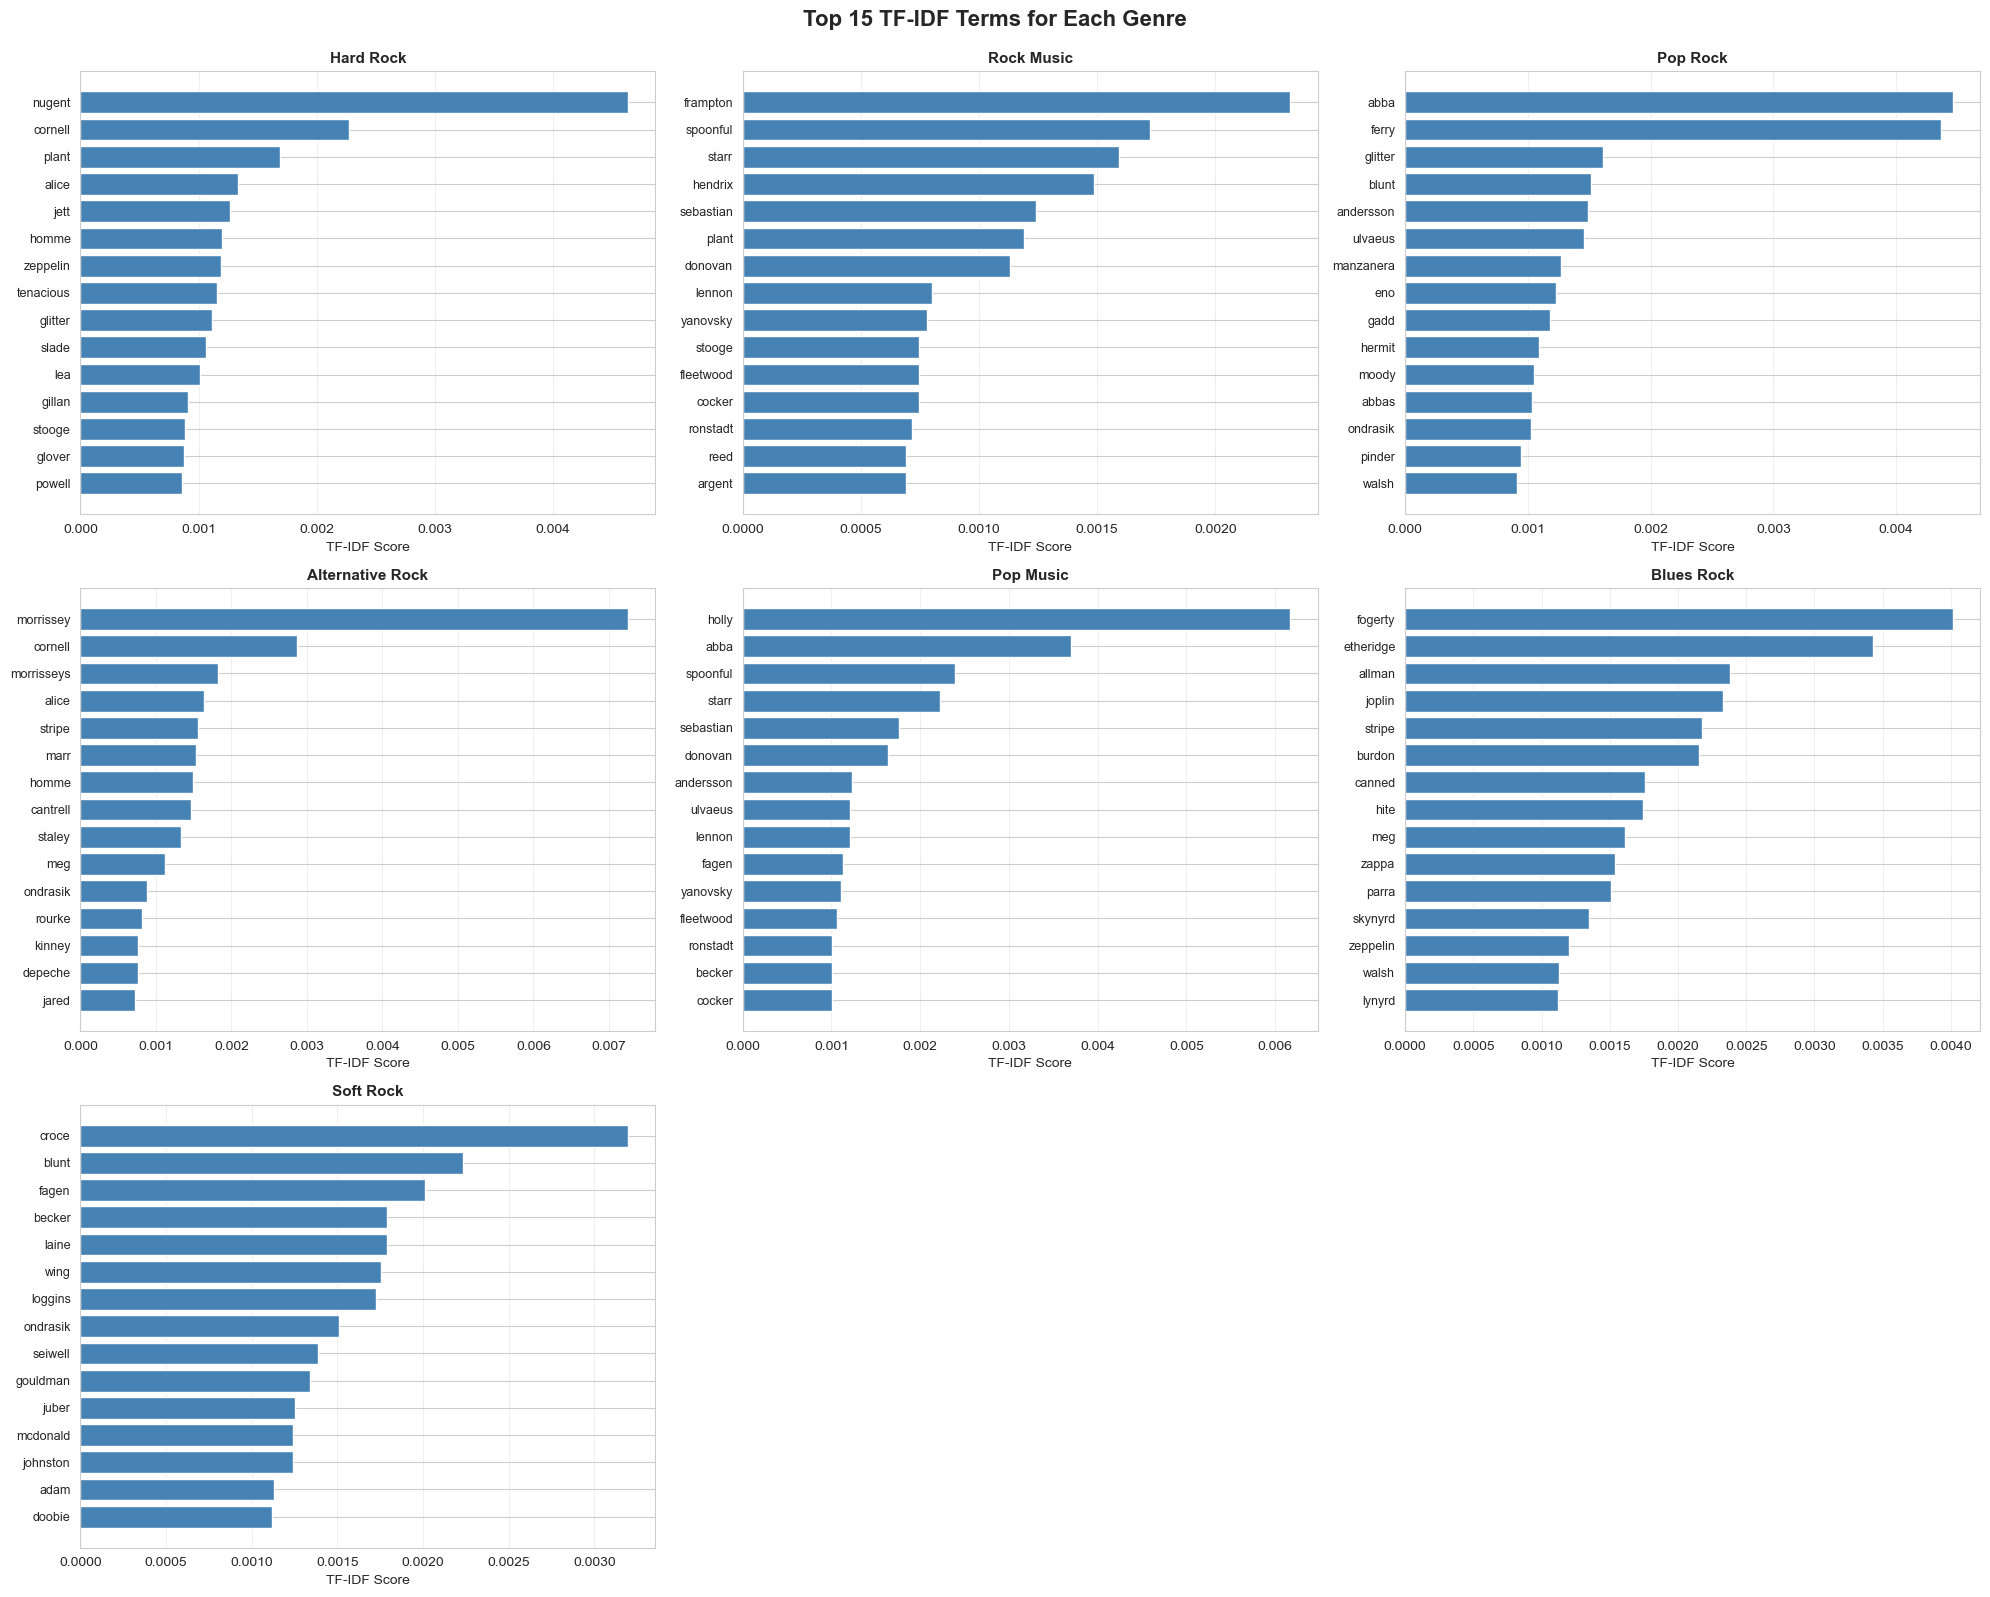

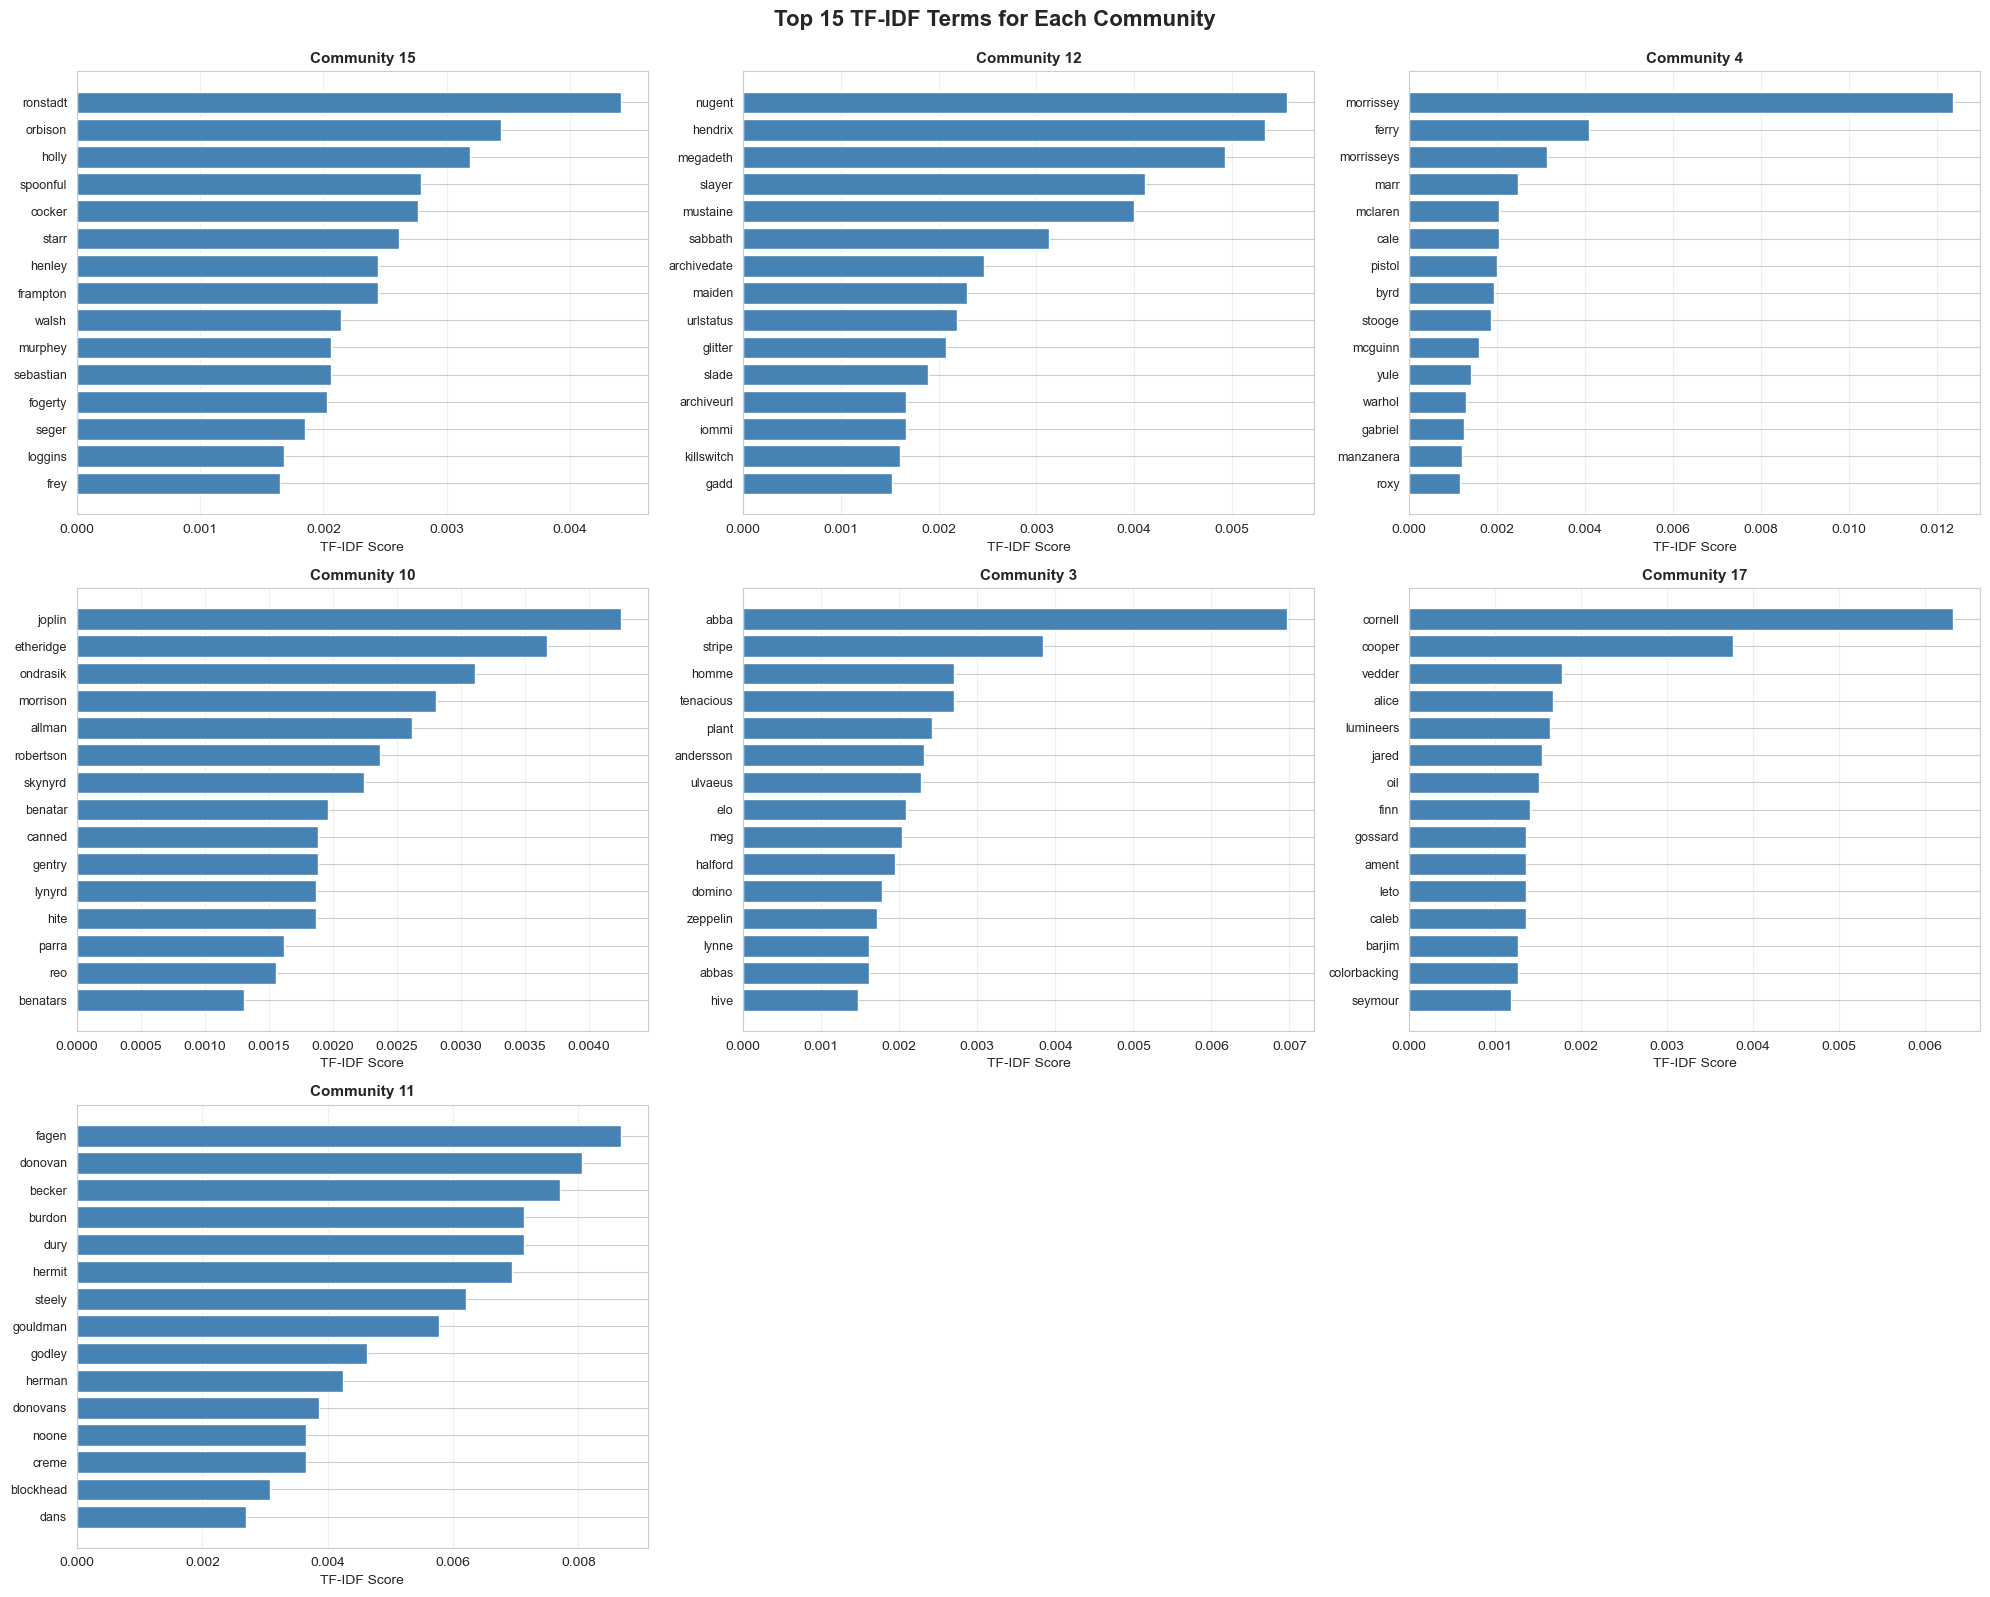

In [241]:
# Visualize genres
visualize_tfidf_terms(
    genre_tf_idf,
    top_genres,
    'Top 15 TF-IDF Terms for Each Genre',
    top_n=15,
    label_formatter=lambda x: x.title()
)

# Visualize communities
visualize_tfidf_terms(
    community_tf_idf,
    top_communities,
    'Top 15 TF-IDF Terms for Each Community',
    top_n=15,
    label_formatter=lambda x: f'Community {x}'
)

In [242]:
def create_tfidf_wordclouds(tfidf_dict, labels, title, colormap_base='viridis'):
    from wordcloud import WordCloud
    
    fig, axes = plt.subplots(3, 3, figsize=(22, 18))
    axes = axes.flatten()
    
    # Different colormaps for variety
    colormaps = ['viridis', 'plasma', 'inferno', 'magma', 'cividis', 'Blues', 'Reds']
    
    for idx, label in enumerate(labels):
        ax = axes[idx]
        
        if label not in tfidf_dict or not tfidf_dict[label]:
            # Handle missing data
            display_label = label.title() if isinstance(label, str) else f'Community {label}'
            ax.text(0.5, 0.5, f'No data\nfor\n{display_label}',
                    ha='center', va='center', fontsize=14, color='gray')
            ax.set_title(display_label, fontsize=12, fontweight='bold', pad=10)
            ax.axis('off')
            continue
        
        # Generate word cloud from TF-IDF scores
        wc = WordCloud(width=800, height=600,
                        background_color='white',
                        colormap=colormaps[idx % len(colormaps)],
                        max_words=100,
                        relative_scaling=0.5,
                        min_font_size=8).generate_from_frequencies(tfidf_dict[label])
        
        # Display
        ax.imshow(wc, interpolation='bilinear')
        
        # Format title based on label type
        if isinstance(label, str):
            display_label = label.title()
        else:
            display_label = f'Community {label}'
        
        ax.set_title(display_label, fontsize=12, fontweight='bold', pad=10)
        ax.axis('off')
    
    # Hide unused subplots
    for idx in range(len(labels), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

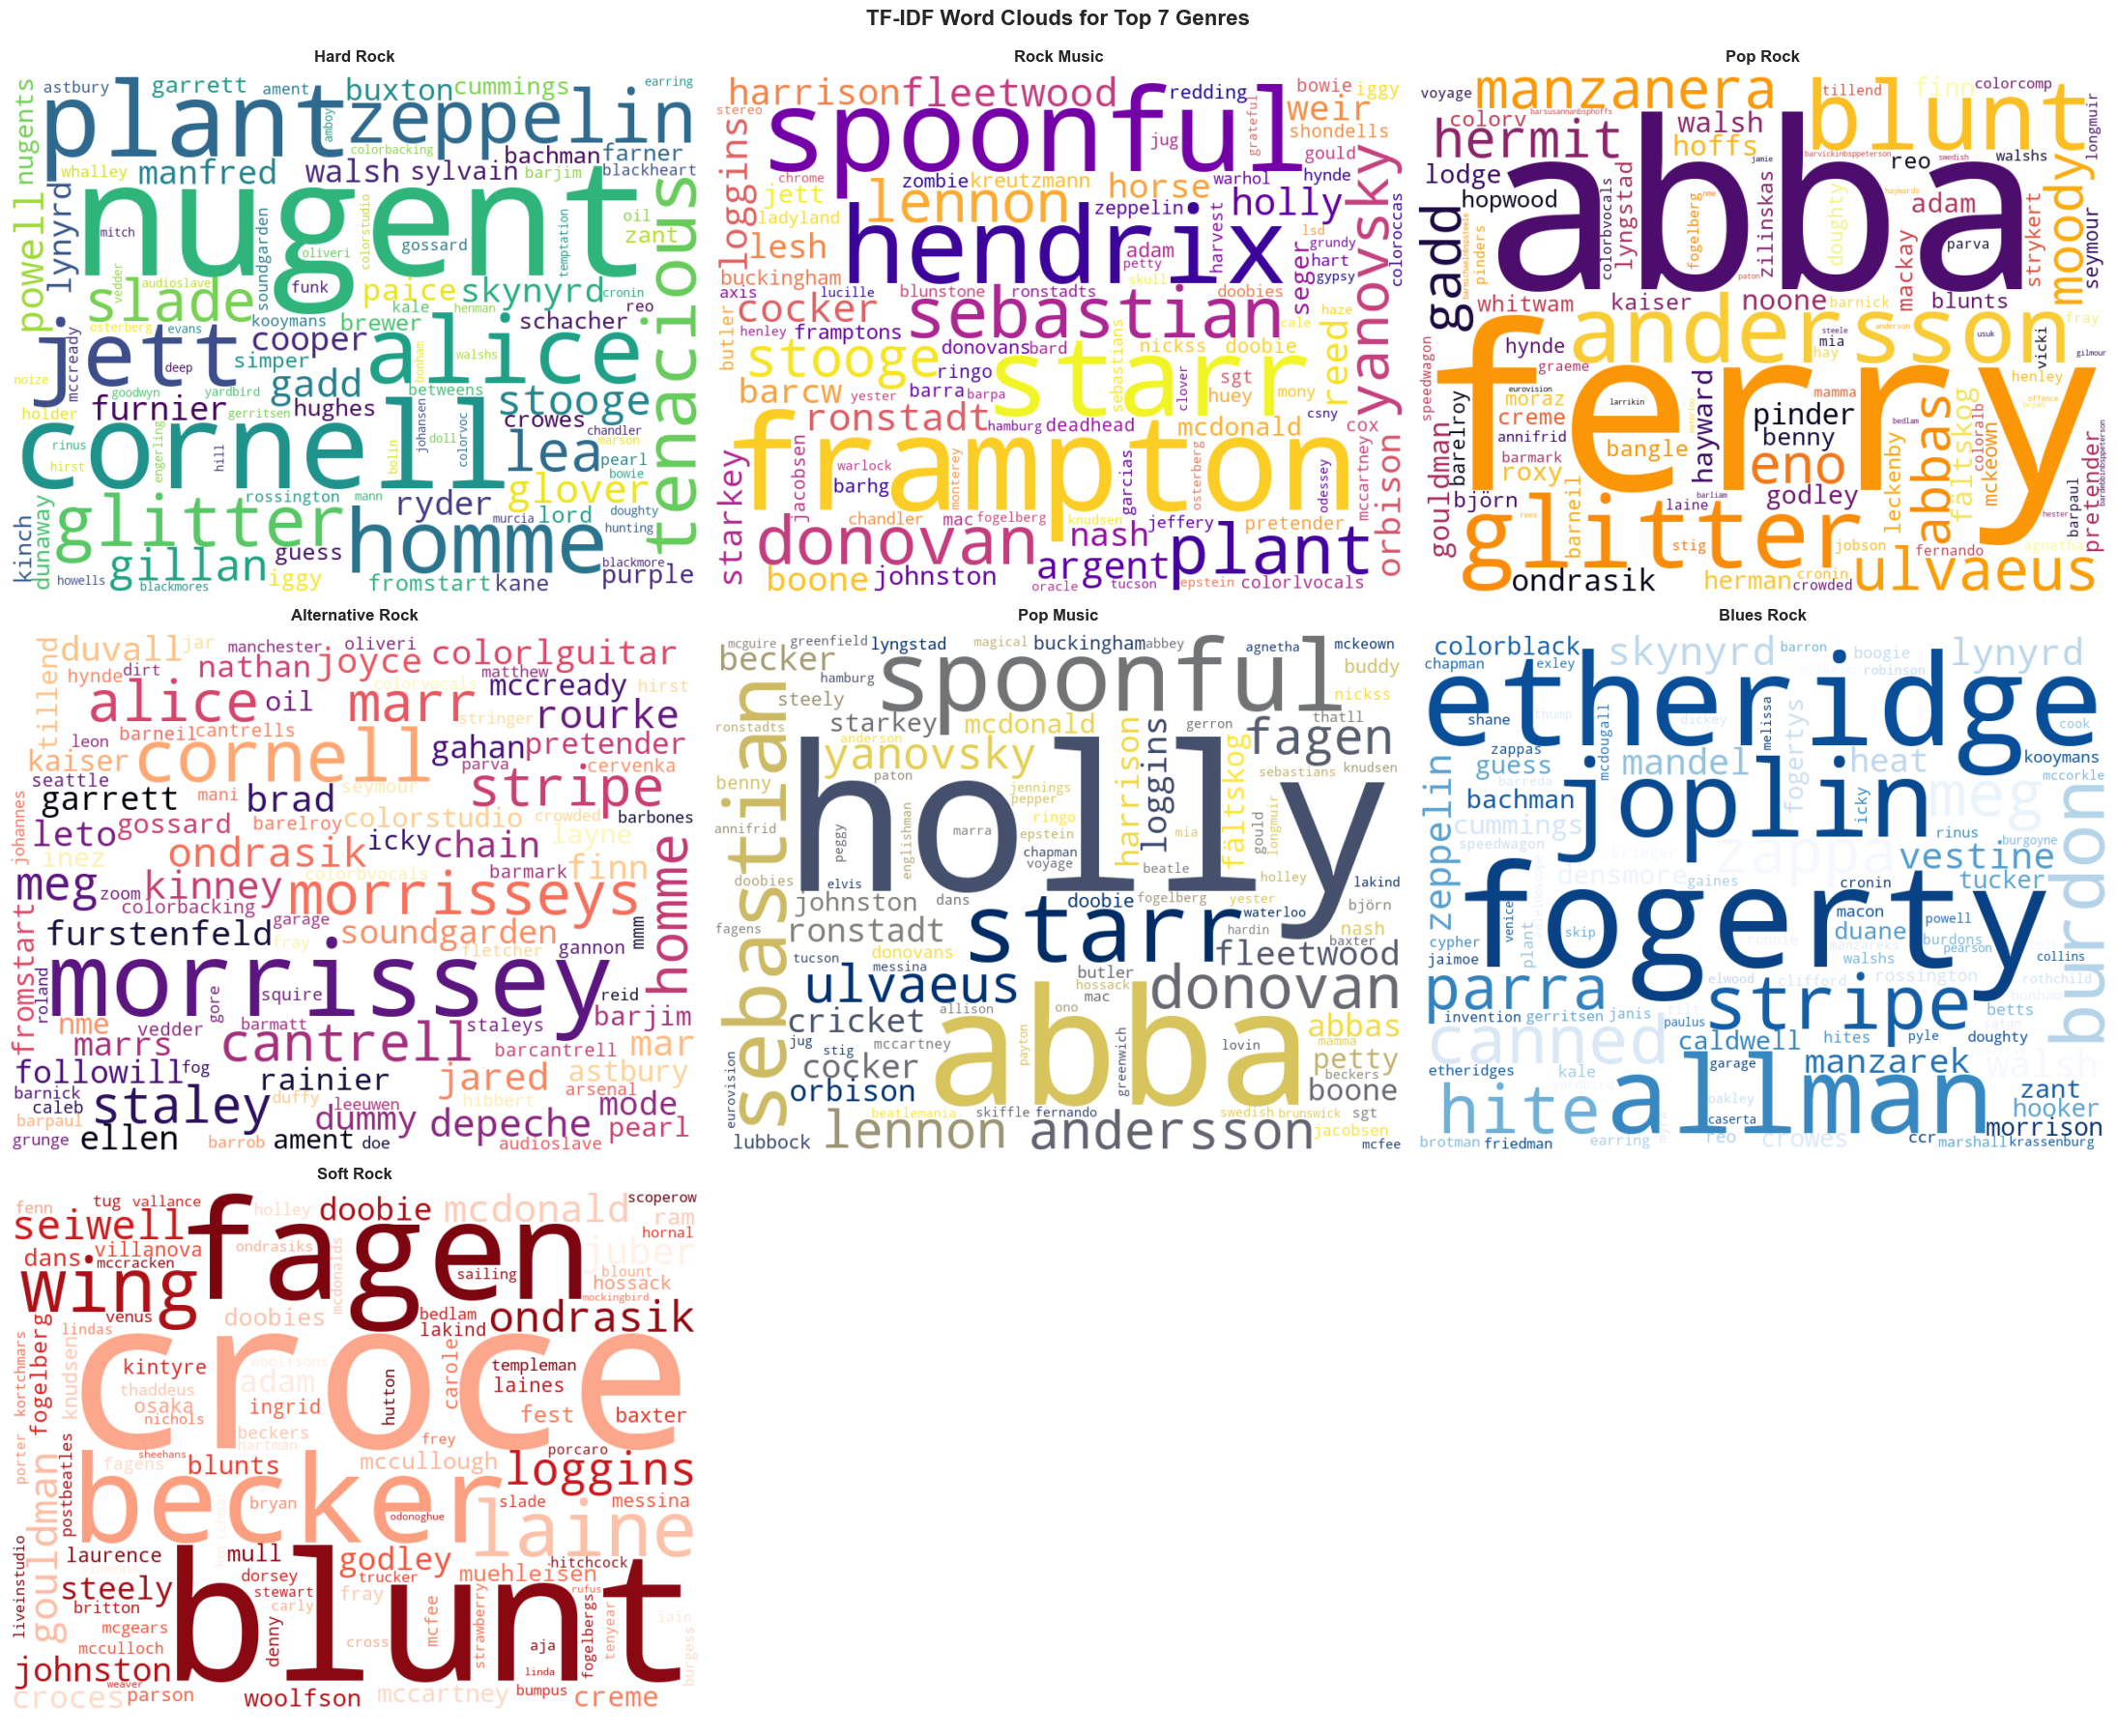

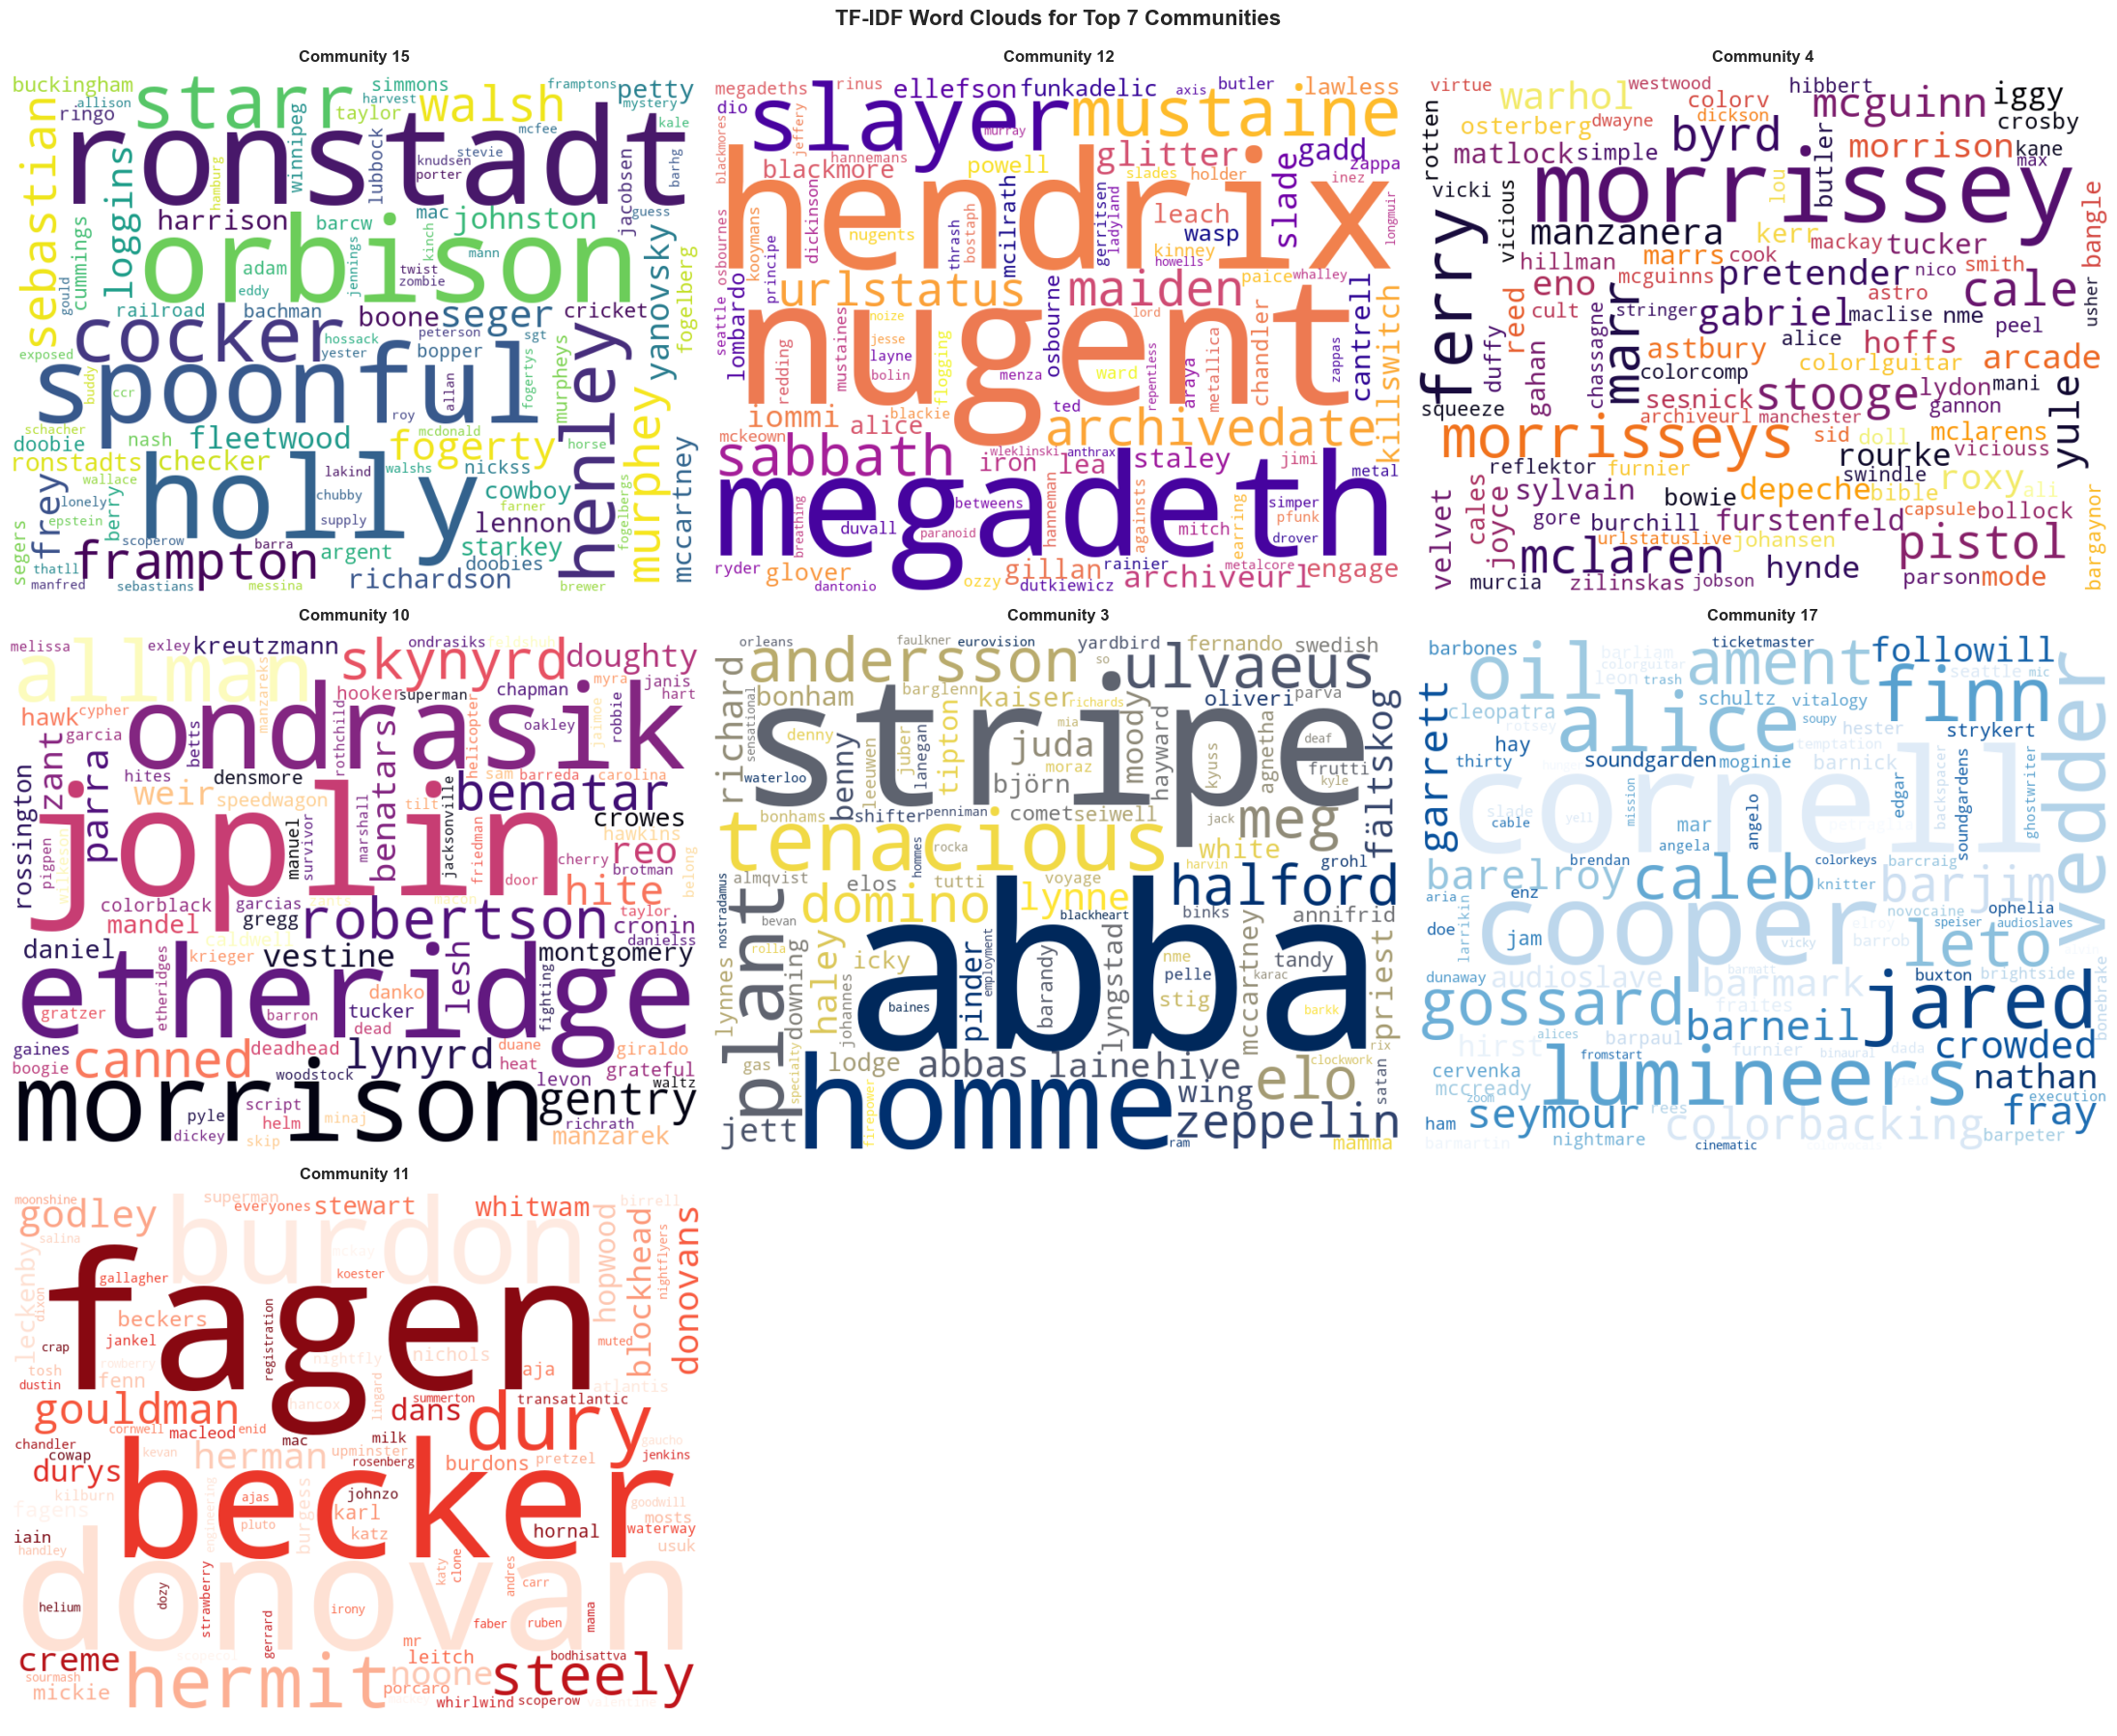

In [243]:
# For genres
create_tfidf_wordclouds(
    genre_tf_idf,
    top_genres,
    'TF-IDF Word Clouds for Top 7 Genres'
)

# For communities
create_tfidf_wordclouds(
    community_tf_idf,
    top_communities,
    'TF-IDF Word Clouds for Top 7 Communities'
)

In [244]:
import pandas as pd
import urllib.request

# Direct download from PLOS ONE supplementary material
url = "https://journals.plos.org/plosone/article/file?id=10.1371/journal.pone.0026752.s001&type=supplementary"

try:
    # Download the file
    urllib.request.urlretrieve(url, "labMT_wordlist.txt")
    print("✓ LabMT wordlist downloaded successfully!")
    
    # Load it as a dataframe
    labmt = pd.read_csv("labMT_wordlist.txt", sep='\t', skiprows=2)
    print(f"  Loaded {len(labmt)} words")
    
    # Create dictionary: word -> happiness score
    labmt_dict = dict(zip(labmt['word'].str.lower(), labmt['happiness_average']))
    
except Exception as e:
    print(f"✗ Error: {e}")

✓ LabMT wordlist downloaded successfully!
  Loaded 10222 words


In [245]:
def calculate_sentiment(tokens, sentiment_dict=labmt_dict):
    # Filter tokens that exist in our sentiment dictionary
    scored_tokens = [sentiment_dict[token] for token in tokens if token in sentiment_dict]
    
    # Return average, or None if no tokens matched
    if scored_tokens:
        return sum(scored_tokens) / len(scored_tokens)
    else:
        return None

In [246]:
import re
from collections import Counter

# Counter for statistics
sentiments_calculated = 0
sentiments_failed = 0
all_sentiments = []

# Iterate through all nodes
for node in network.nodes():
    # Get the page content
    content = network.nodes[node].get('content', '')
    
    if not content:
        network.nodes[node]['sentiment'] = None
        sentiments_failed += 1
        continue
    
    content = load_content(content)
    
    # Clean and tokenize
    tokens = clean_and_tokenize(content)
    
    # Calculate sentiment
    sentiment = calculate_sentiment(tokens)
    
    # Store as node attribute
    network.nodes[node]['sentiment'] = sentiment
    
    if sentiment is not None:
        sentiments_calculated += 1
        all_sentiments.append(sentiment)
    else:
        sentiments_failed += 1

print(f"✓ Sentiment calculation complete!")
print(f"  Sentiments calculated: {sentiments_calculated}")
print(f"  Failed (no matching words): {sentiments_failed}")
print(f"  Total nodes: {network.number_of_nodes()}")

✓ Sentiment calculation complete!
  Sentiments calculated: 457
  Failed (no matching words): 27
  Total nodes: 484


In [247]:
import numpy as np

# Calculate statistics
sentiment_mean = np.mean(all_sentiments)
sentiment_median = np.median(all_sentiments)
sentiment_variance = np.var(all_sentiments)
sentiment_std = np.std(all_sentiments)
sentiment_25th = np.percentile(all_sentiments, 25)
sentiment_75th = np.percentile(all_sentiments, 75)
sentiment_min = np.min(all_sentiments)
sentiment_max = np.max(all_sentiments)

print("Sentiment Statistics:")
print(f"Mean: {sentiment_mean:.2f}")
print(f"Median: {sentiment_median:.2f}")
print(f"Variance: {sentiment_variance:.2f}")
print(f"Std Deviation: {sentiment_std:.2f}")
print(f"25th Percentile (Q1): {sentiment_25th:.2f}")
print(f"75th Percentile (Q3): {sentiment_75th:.2f}")
print(f"IQR (Q3-Q1): {sentiment_75th - sentiment_25th:.2f}")
print(f"Minimum: {sentiment_min:.2f}")
print(f"Maximum: {sentiment_max:.2f}")
print(f"Range: {sentiment_max - sentiment_min:.2f}")
print(f"Sample size: {len(all_sentiments)} pages")

Sentiment Statistics:
Mean: 5.83
Median: 5.84
Variance: 0.02
Std Deviation: 0.13
25th Percentile (Q1): 5.77
75th Percentile (Q3): 5.91
IQR (Q3-Q1): 0.14
Minimum: 5.16
Maximum: 6.27
Range: 1.12
Sample size: 457 pages


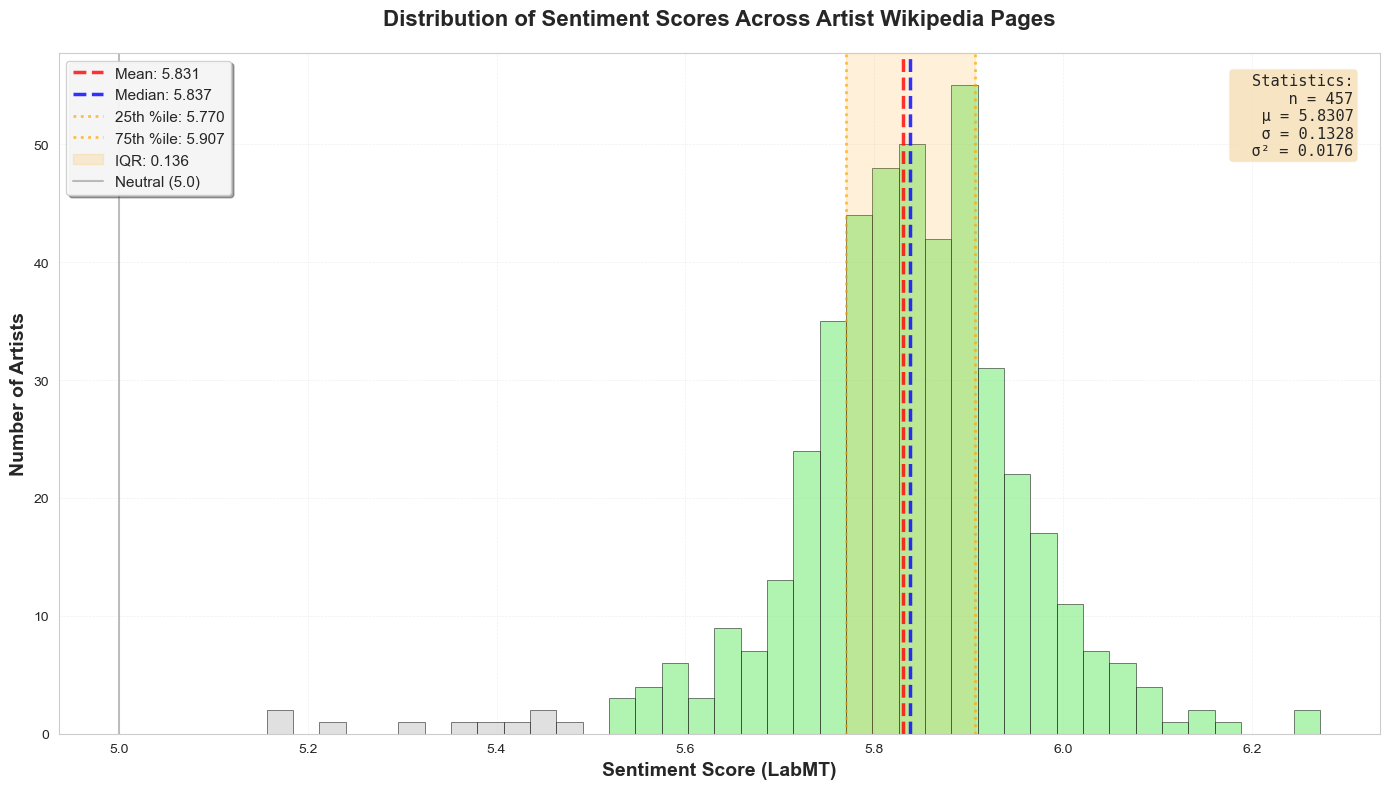

In [248]:
import matplotlib.pyplot as plt

# Set style for a beautiful plot
plt.rcParams['figure.facecolor'] = 'white'

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Create histogram
n, bins, patches = ax.hist(all_sentiments, bins=40, alpha=0.7, color='steelblue',
                        edgecolor='black', linewidth=0.5, density=False)

# Color code the bars based on sentiment
for i, patch in enumerate(patches):
    bin_center = (bins[i] + bins[i+1]) / 2
    if bin_center > 5.5:
        patch.set_facecolor('#90EE90')  # Light green for positive
    elif bin_center < 4.5:
        patch.set_facecolor('#FFB6C6')  # Light red for negative
    else:
        patch.set_facecolor('#D3D3D3')  # Gray for neutral

# Add vertical lines for statistics
ax.axvline(sentiment_mean, color='red', linestyle='--', linewidth=2.5,
        label=f'Mean: {sentiment_mean:.3f}', alpha=0.8)
ax.axvline(sentiment_median, color='blue', linestyle='--', linewidth=2.5,
        label=f'Median: {sentiment_median:.3f}', alpha=0.8)
ax.axvline(sentiment_25th, color='orange', linestyle=':', linewidth=2,
        label=f'25th %ile: {sentiment_25th:.3f}', alpha=0.7)
ax.axvline(sentiment_75th, color='orange', linestyle=':', linewidth=2,
        label=f'75th %ile: {sentiment_75th:.3f}', alpha=0.7)

# Shade the IQR region
ax.axvspan(sentiment_25th, sentiment_75th, alpha=0.15, color='orange',
        label=f'IQR: {sentiment_75th - sentiment_25th:.3f}')

# Add neutral line at 5.0
ax.axvline(5.0, color='gray', linestyle='-', linewidth=1.5, alpha=0.5,
        label='Neutral (5.0)')

# Labels and title
ax.set_xlabel('Sentiment Score (LabMT)', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Artists', fontsize=14, fontweight='bold')
ax.set_title('Distribution of Sentiment Scores Across Artist Wikipedia Pages',
            fontsize=16, fontweight='bold', pad=20)

# Add legend
ax.legend(loc='upper left', fontsize=11, framealpha=0.9, shadow=True)

# Add text box with statistics
textstr = '\n'.join([
    f'Statistics:',
    f'  n = {len(all_sentiments)}',
    f'  μ = {sentiment_mean:.4f}',
    f'  σ = {sentiment_std:.4f}',
    f'  σ² = {sentiment_variance:.4f}',
])
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right', bbox=props,
        family='monospace')

# Grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Adjust layout
plt.tight_layout()
plt.show()

In [249]:
# Create a list of (artist, sentiment) tuples for all artists with valid sentiment
artist_sentiments = []
for node in network.nodes():
    sentiment = network.nodes[node]['sentiment']
    if sentiment is not None:
        artist_sentiments.append((node, sentiment))

# Sort by sentiment
artist_sentiments.sort(key=lambda x: x[1])

# Get top 10 saddest and happiest
saddest_10 = artist_sentiments[:10]
happiest_10 = artist_sentiments[-10:][::-1]

print("Top 10 Saddest Artists")
for i, (artist, sentiment) in enumerate(saddest_10, 1):
    print(f"{i:2d}. {artist:40s} - Sentiment: {sentiment:.2f}")

print("\nTop 10 Happiest Artists")
for i, (artist, sentiment) in enumerate(happiest_10, 1):
    print(f"{i:2d}. {artist:40s} - Sentiment: {sentiment:.4f}")

# Calculate difference
if len(happiest_10) > 0 and len(saddest_10) > 0:
    sentiment_range = happiest_10[0][1] - saddest_10[0][1]
    print(f"\nSentiment range (happiest - saddest): {sentiment_range:.4f}")

Top 10 Saddest Artists
 1. poison (american band)|poison            - Sentiment: 5.16
 2. everclear (band)|everclear               - Sentiment: 5.17
 3. garbage (band)|garbage                   - Sentiment: 5.23
 4. keane (band)|keane                       - Sentiment: 5.32
 5. anthrax (american band)|anthrax          - Sentiment: 5.36
 6. traffic (band)|traffic                   - Sentiment: 5.40
 7. 311 (band)|311                           - Sentiment: 5.43
 8. ghost (swedish band)|ghost               - Sentiment: 5.44
 9. hole (band)|hole                         - Sentiment: 5.45
10. 38 special (band)|.38 special            - Sentiment: 5.49

Top 10 Happiest Artists
 1. steppenwolf (band)|steppenwolf           - Sentiment: 6.2720
 2. journey (band)|journey                   - Sentiment: 6.2489
 3. queen (band)|queen                       - Sentiment: 6.1649
 4. pixies (band)|pixies                     - Sentiment: 6.1550
 5. live (band)|live                         - Sentiment: 6.15

In [250]:
# Calculate average sentiment for each community
community_sentiments = {}

for comm_id in top_communities:
    members = louvain_dict[comm_id]
    
    # Get sentiments for all members of this community
    sentiments = []
    for artist in members:
        if artist in network.nodes():
            sentiment = network.nodes[artist].get('sentiment', None)
            if sentiment is not None:
                sentiments.append(sentiment)
    
    # Calculate average
    if sentiments:
        avg_sentiment = np.mean(sentiments)
        community_sentiments[comm_id] = {
            'avg_sentiment': avg_sentiment,
            'size': len(members),
            'sentiment_count': len(sentiments),
            'members': members
        }
        print(f"\nCommunity {comm_id}:")
        print(f"  Size: {len(members)} members")
        print(f"  Average sentiment: {avg_sentiment:.4f}")
    else:
        print(f"\nCommunity {comm_id}:")
        print(f"  Size: {len(members)} members")
        print(f"  No sentiment data available")


Community 15:
  Size: 36 members
  Average sentiment: 5.8609

Community 12:
  Size: 22 members
  Average sentiment: 5.7665

Community 4:
  Size: 22 members
  Average sentiment: 5.8212

Community 10:
  Size: 21 members
  Average sentiment: 5.8397

Community 3:
  Size: 18 members
  Average sentiment: 5.8648

Community 17:
  Size: 12 members
  Average sentiment: 5.8758

Community 11:
  Size: 7 members
  Average sentiment: 5.8279


In [251]:
# Name each community by the 3 most connected bands
community_names = {}

print("Naming Top Communities Based on Most Connected Bands:")

for comm_id in top_communities:
    if comm_id not in community_sentiments:
        continue
    
    members = community_sentiments[comm_id]['members']
    
    # Calculate degree centrality within the community (subgraph)
    community_subgraph = network.subgraph(members)
    degrees = dict(community_subgraph.degree())
    
    # Sort by degree and get top 3 (or fewer if community is small)
    top_3 = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:3]
    top_3_names = [name for name, degree in top_3]
    
    # Create a descriptive name (handle communities with fewer than 3 members)
    if len(top_3_names) >= 3:
        community_name = f"{top_3_names[0]}, {top_3_names[1]}, {top_3_names[2]}"
    elif len(top_3_names) == 2:
        community_name = f"{top_3_names[0]}, {top_3_names[1]}"
    elif len(top_3_names) == 1:
        community_name = top_3_names[0]
    else:
        community_name = f"Community {comm_id}"
    
    community_names[comm_id] = {
        'short_name': community_name,
        'top_bands': top_3_names,
        'degrees': [degree for name, degree in top_3]
    }
    
    print(f"\nCommunity {comm_id}:")
    print(f"  Name: {community_name}")

Naming Top Communities Based on Most Connected Bands:

Community 15:
  Name: the beatles, joe walsh, buddy holly

Community 12:
  Name: deep purple, black sabbath, jimi hendrix

Community 4:
  Name: the smiths, morrissey, sex pistols

Community 10:
  Name: janis joplin, the allman brothers band, lynyrd skynyrd

Community 3:
  Name: led zeppelin, robert plant, judas priest

Community 17:
  Name: pearl jam, alice cooper, midnight oil

Community 11:
  Name: donovan, herman's hermits, steely dan


In [252]:
# Sort communities by sentiment
sorted_communities = sorted(community_sentiments.items(), 
                        key=lambda x: x[1]['avg_sentiment'])

num_communities = len(top_communities)

# Determine how many to show (3 if >5 communities, 2 if ≤5)
num_to_show = 3

saddest_communities = sorted_communities[:num_to_show]
happiest_communities = sorted_communities[-num_to_show:][::-1]

print(f"Top {num_to_show} saddest communities")

for i, (comm_id, data) in enumerate(saddest_communities, 1):
    name = community_names[comm_id]['short_name']
    sentiment = data['avg_sentiment']
    size = data['size']
    print(f"\n{i}. Community {comm_id}: {name}")
    print(f"   Average Sentiment: {sentiment:.4f}")
    print(f"   Size: {size} members")
    print(f"   Difference from overall mean: {sentiment - sentiment_mean:+.4f}")

print(f"\nTop {num_to_show} happiest communities")

for i, (comm_id, data) in enumerate(happiest_communities, 1):
    name = community_names[comm_id]['short_name']
    sentiment = data['avg_sentiment']
    size = data['size']
    print(f"\n{i}. Community {comm_id}: {name}")
    print(f"   Average Sentiment: {sentiment:.4f}")
    print(f"   Size: {size} members")
    print(f"   Difference from overall mean: {sentiment - sentiment_mean:+.4f}")

Top 3 saddest communities

1. Community 12: deep purple, black sabbath, jimi hendrix
   Average Sentiment: 5.7665
   Size: 22 members
   Difference from overall mean: -0.0642

2. Community 4: the smiths, morrissey, sex pistols
   Average Sentiment: 5.8212
   Size: 22 members
   Difference from overall mean: -0.0095

3. Community 11: donovan, herman's hermits, steely dan
   Average Sentiment: 5.8279
   Size: 7 members
   Difference from overall mean: -0.0028

Top 3 happiest communities

1. Community 17: pearl jam, alice cooper, midnight oil
   Average Sentiment: 5.8758
   Size: 12 members
   Difference from overall mean: +0.0451

2. Community 3: led zeppelin, robert plant, judas priest
   Average Sentiment: 5.8648
   Size: 18 members
   Difference from overall mean: +0.0341

3. Community 15: the beatles, joe walsh, buddy holly
   Average Sentiment: 5.8609
   Size: 36 members
   Difference from overall mean: +0.0302


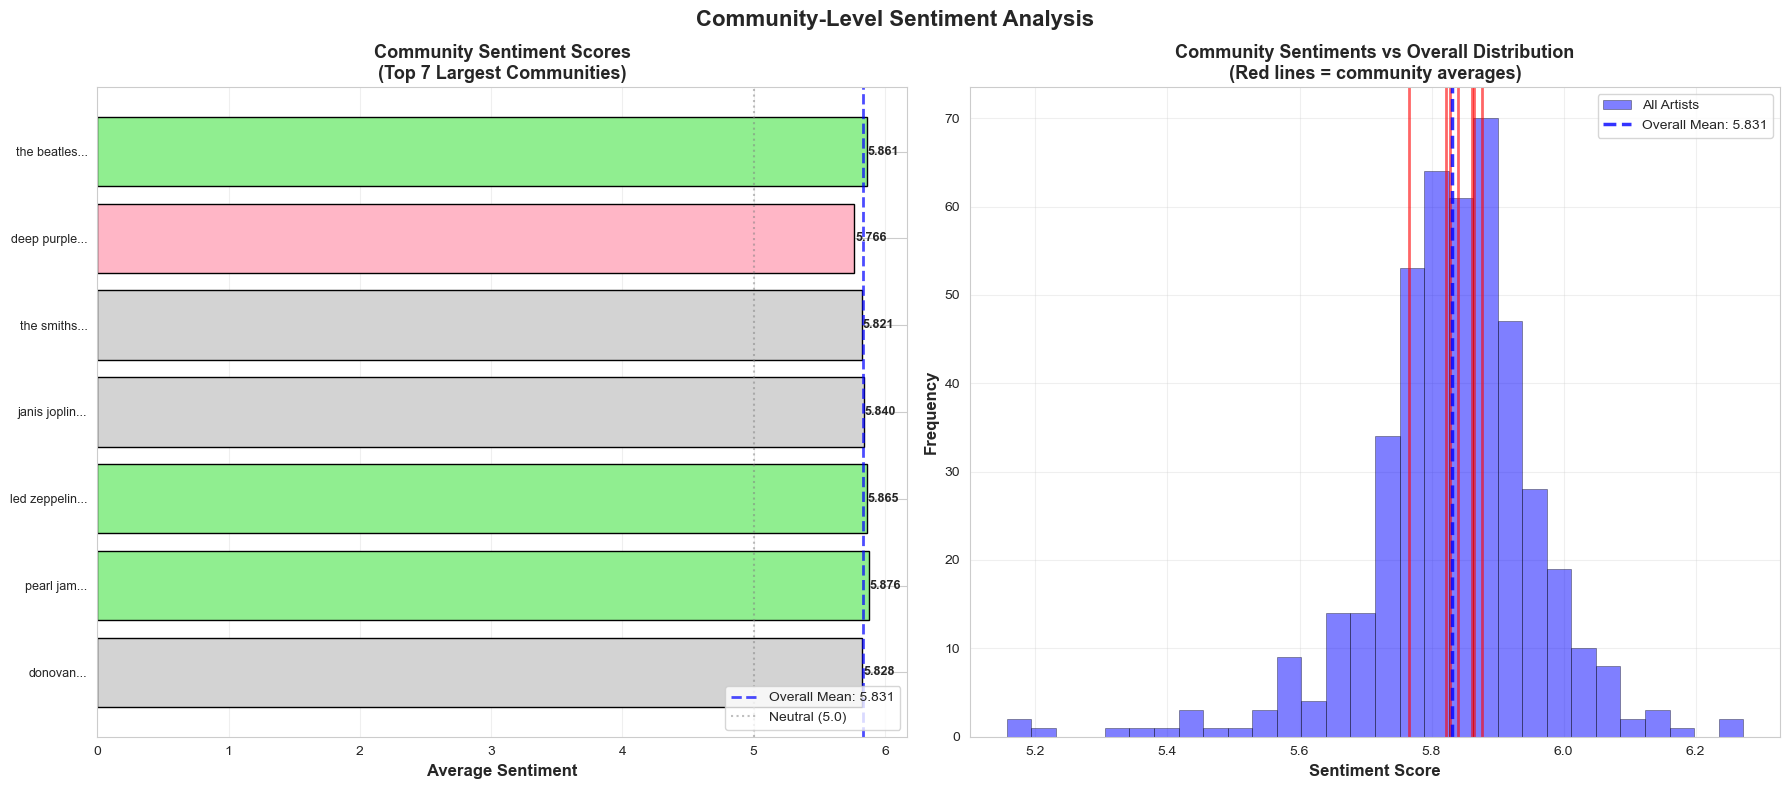

In [253]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Left plot: Bar chart of community sentiments
comm_ids = []
comm_sentiments = []
comm_names_short = []

for comm_id in top_communities:
    if comm_id in community_sentiments:
        comm_ids.append(f"C{comm_id}")
        comm_sentiments.append(community_sentiments[comm_id]['avg_sentiment'])
        # Shorten name for display
        full_name = community_names[comm_id]['short_name']
        short_name = full_name.split(',')[0] + "..."  # Just first band + "..."
        comm_names_short.append(short_name)

# Color code bars
colors = []
for sent in comm_sentiments:
    if sent > sentiment_mean + 0.02:
        colors.append('#90EE90')  # Green for above average
    elif sent < sentiment_mean - 0.02:
        colors.append('#FFB6C6')  # Red for below average
    else:
        colors.append('#D3D3D3')  # Gray for near average

y_pos = range(len(comm_ids))
bars = ax1.barh(y_pos, comm_sentiments, color=colors, edgecolor='black', linewidth=1)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(comm_names_short, fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('Average Sentiment', fontsize=12, fontweight='bold')
ax1.set_title(f'Community Sentiment Scores\n(Top {num_communities} Largest Communities)',
            fontsize=13, fontweight='bold')
ax1.axvline(sentiment_mean, color='blue', linestyle='--', linewidth=2,
            label=f'Overall Mean: {sentiment_mean:.3f}', alpha=0.7)
ax1.axvline(5.0, color='gray', linestyle=':', linewidth=1.5, label='Neutral (5.0)', alpha=0.5)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, sent) in enumerate(zip(bars, comm_sentiments)):
    ax1.text(sent + 0.005, i, f'{sent:.3f}', va='center', fontsize=9, fontweight='bold')

# Right plot: Distribution comparison
ax2.hist(all_sentiments, bins=30, alpha=0.5, color='blue', label='All Artists',
        edgecolor='black', linewidth=0.5)

# Overlay community average sentiments as vertical lines
for comm_id, sent in zip(comm_ids, comm_sentiments):
    ax2.axvline(sent, color='red', linestyle='-', linewidth=2, alpha=0.6)

ax2.axvline(sentiment_mean, color='blue', linestyle='--', linewidth=2.5,
            label=f'Overall Mean: {sentiment_mean:.3f}', alpha=0.8)
ax2.set_xlabel('Sentiment Score', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Community Sentiments vs Overall Distribution\n(Red lines = community averages)',
            fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.suptitle('Community-Level Sentiment Analysis', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()